# import libraries

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

from scipy import stats
from scipy.stats import ks_2samp


sns.set_theme(style="whitegrid")

fs=24

## Import data

In [15]:
df_spans_1000 = pd.read_csv("../../../Data/E2EGHG/span_total_1000.csv")

In [16]:
# create reduced dataset for modeling
df = df_spans_1000.drop([ 'samples', 'zone', 'timestamp',
        'kepler_duration_sum_ms_span', 'kepler_energy_joules_span',
         'start_energy_joules_span',
        'end_energy_joules_span', 'start_energy_joules_kepler',
        'end_energy_joules_kepler', 'exper_name', 'interval_ms', 
        'sleep_ms',  'idle_scrapping_ms', 'source_csv'], axis=1)
df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.000
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.000
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.000
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.000
4,3c9bd42a5d09c0f8471db4b31e7cdda7,0.123870,20,0.125
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.750
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.000
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.000
8,9d3381d559c8e3e41be242cefd0c2c15,1.780661,500,3.125
9,9ad937051ed5fb795c71388b740c224e,0.334675,100,25.000


#### filter out rows with too short active_interval_ms (< 25.0 ms are removed)

In [17]:
df = df.query('active_interval_ms >= 25.0')
df

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75
...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00


### Get Median E for each cpu_ms

In [18]:
df_median_e_cpu_1000 = df[['energy_joules_span','cpu_ms']].copy()
df_median_e_cpu_1000 = df_median_e_cpu_1000.groupby(['cpu_ms'], as_index=False).median()
df_median_e_cpu_1000

,cpu_ms,energy_joules_span
0,50,0.128859
1,100,0.285802
2,150,0.455825
3,250,0.844799
4,375,1.329002
5,500,1.819178
6,625,2.282161
7,750,2.829188
8,1000,3.792336
9,1250,4.785089


### add column with median energy for that cpu_ms to each trace_id

In [19]:
cpu_ms_vals = np.unique(df['cpu_ms'])
for i in cpu_ms_vals:
    df.loc[df['cpu_ms'] == i, 'median_energy_cpu_ms'] = df_median_e_cpu_1000[df_median_e_cpu_1000['cpu_ms'] == i].energy_joules_span.values[0]

df.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.792336
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.455825
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.455825
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.795812
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.669263
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.00,0.285802
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.00,0.285802
9,9ad937051ed5fb795c71388b740c224e,0.334675,100,25.00,0.285802
10,53ce784698112331713b74d2beee804a,0.444463,100,50.00,0.285802
11,99648071e9c6152e9efb11bf8f8520b2,0.521254,150,25.00,0.455825


### calculate deviation per trace E from median for that cpu_ms

In [20]:
df['energy_devation'] = (df.median_energy_cpu_ms - df.energy_joules_span) 

### and add columns for % deviation from median for that cpu_ms, sampling ratio, and accuracy
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [21]:
df['energy_deviation_pct'] = 100 * df.energy_devation / df.median_energy_cpu_ms
df['sampling_ratio'] = df.cpu_ms / df.active_interval_ms
df['energy_deviation_pct_abs'] = np.abs(df.energy_deviation_pct)

In [22]:
df


,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.792336,-0.381900,-10.070296,20.000000,10.070296
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.455825,-0.424935,-93.223488,1.000000,93.223488
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.455825,0.014090,3.090992,2.000000,3.090992
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.795812,0.001889,0.024225,40.000000,0.024225
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.669263,-0.099719,-0.934643,40.000000,0.934643
...,...,...,...,...,...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00,0.844799,-0.052722,-6.240774,2.000000,6.240774
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00,11.760279,2.728986,23.205113,1.333333,23.205113
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00,0.128859,0.031773,24.657183,2.000000,24.657183
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00,0.285802,0.120961,42.323256,1.333333,42.323256


In [29]:
# copy data to preserve original
df_filtered_1000 = df.copy()

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,recip_sampling_ratio
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.792336,-0.381900,-10.070296,20.000000,10.070296,0.050
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.455825,-0.424935,-93.223488,1.000000,93.223488,1.000
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.455825,0.014090,3.090992,2.000000,3.090992,0.500
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.795812,0.001889,0.024225,40.000000,0.024225,0.025
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.669263,-0.099719,-0.934643,40.000000,0.934643,0.025
...,...,...,...,...,...,...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00,0.844799,-0.052722,-6.240774,2.000000,6.240774,0.500
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00,11.760279,2.728986,23.205113,1.333333,23.205113,0.750
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00,0.128859,0.031773,24.657183,2.000000,24.657183,0.500
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00,0.285802,0.120961,42.323256,1.333333,42.323256,0.750


In [30]:
df_median_dev_1000 = df_filtered_1000.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
#df_std_dev_1000 = df_filtered_1000.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).std()

df_median_dev_1000 = df_median_dev_1000.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
#df_mean_dev_1000['std_energy_deviation'] = df_std_dev_1000['energy_deviation_pct_abs']

#df_mean_dev_1000['conf_int_95'] = 1.96 * df_mean_dev_1000.std_energy_deviation / np.sqrt(100)
df_median_dev_1000['recip_sampling_ratio'] = 1 / df_median_dev_1000.sampling_ratio
df_median_dev_1000

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio
0,50,1.000000,32.310898,1.0000
1,50,1.333333,27.400104,0.7500
2,50,2.000000,32.807953,0.5000
3,100,1.000000,24.012295,1.0000
4,100,1.333333,26.807242,0.7500
...,...,...,...,...
105,3000,4.000000,7.814742,0.2500
106,3000,10.000000,3.853761,0.1000
107,3000,20.000000,2.849205,0.0500
108,3000,40.000000,3.234945,0.0250


Text(37.53125, 0.5, '$Median ({\\Delta E})$ %')

<Figure size 1000x1000 with 0 Axes>

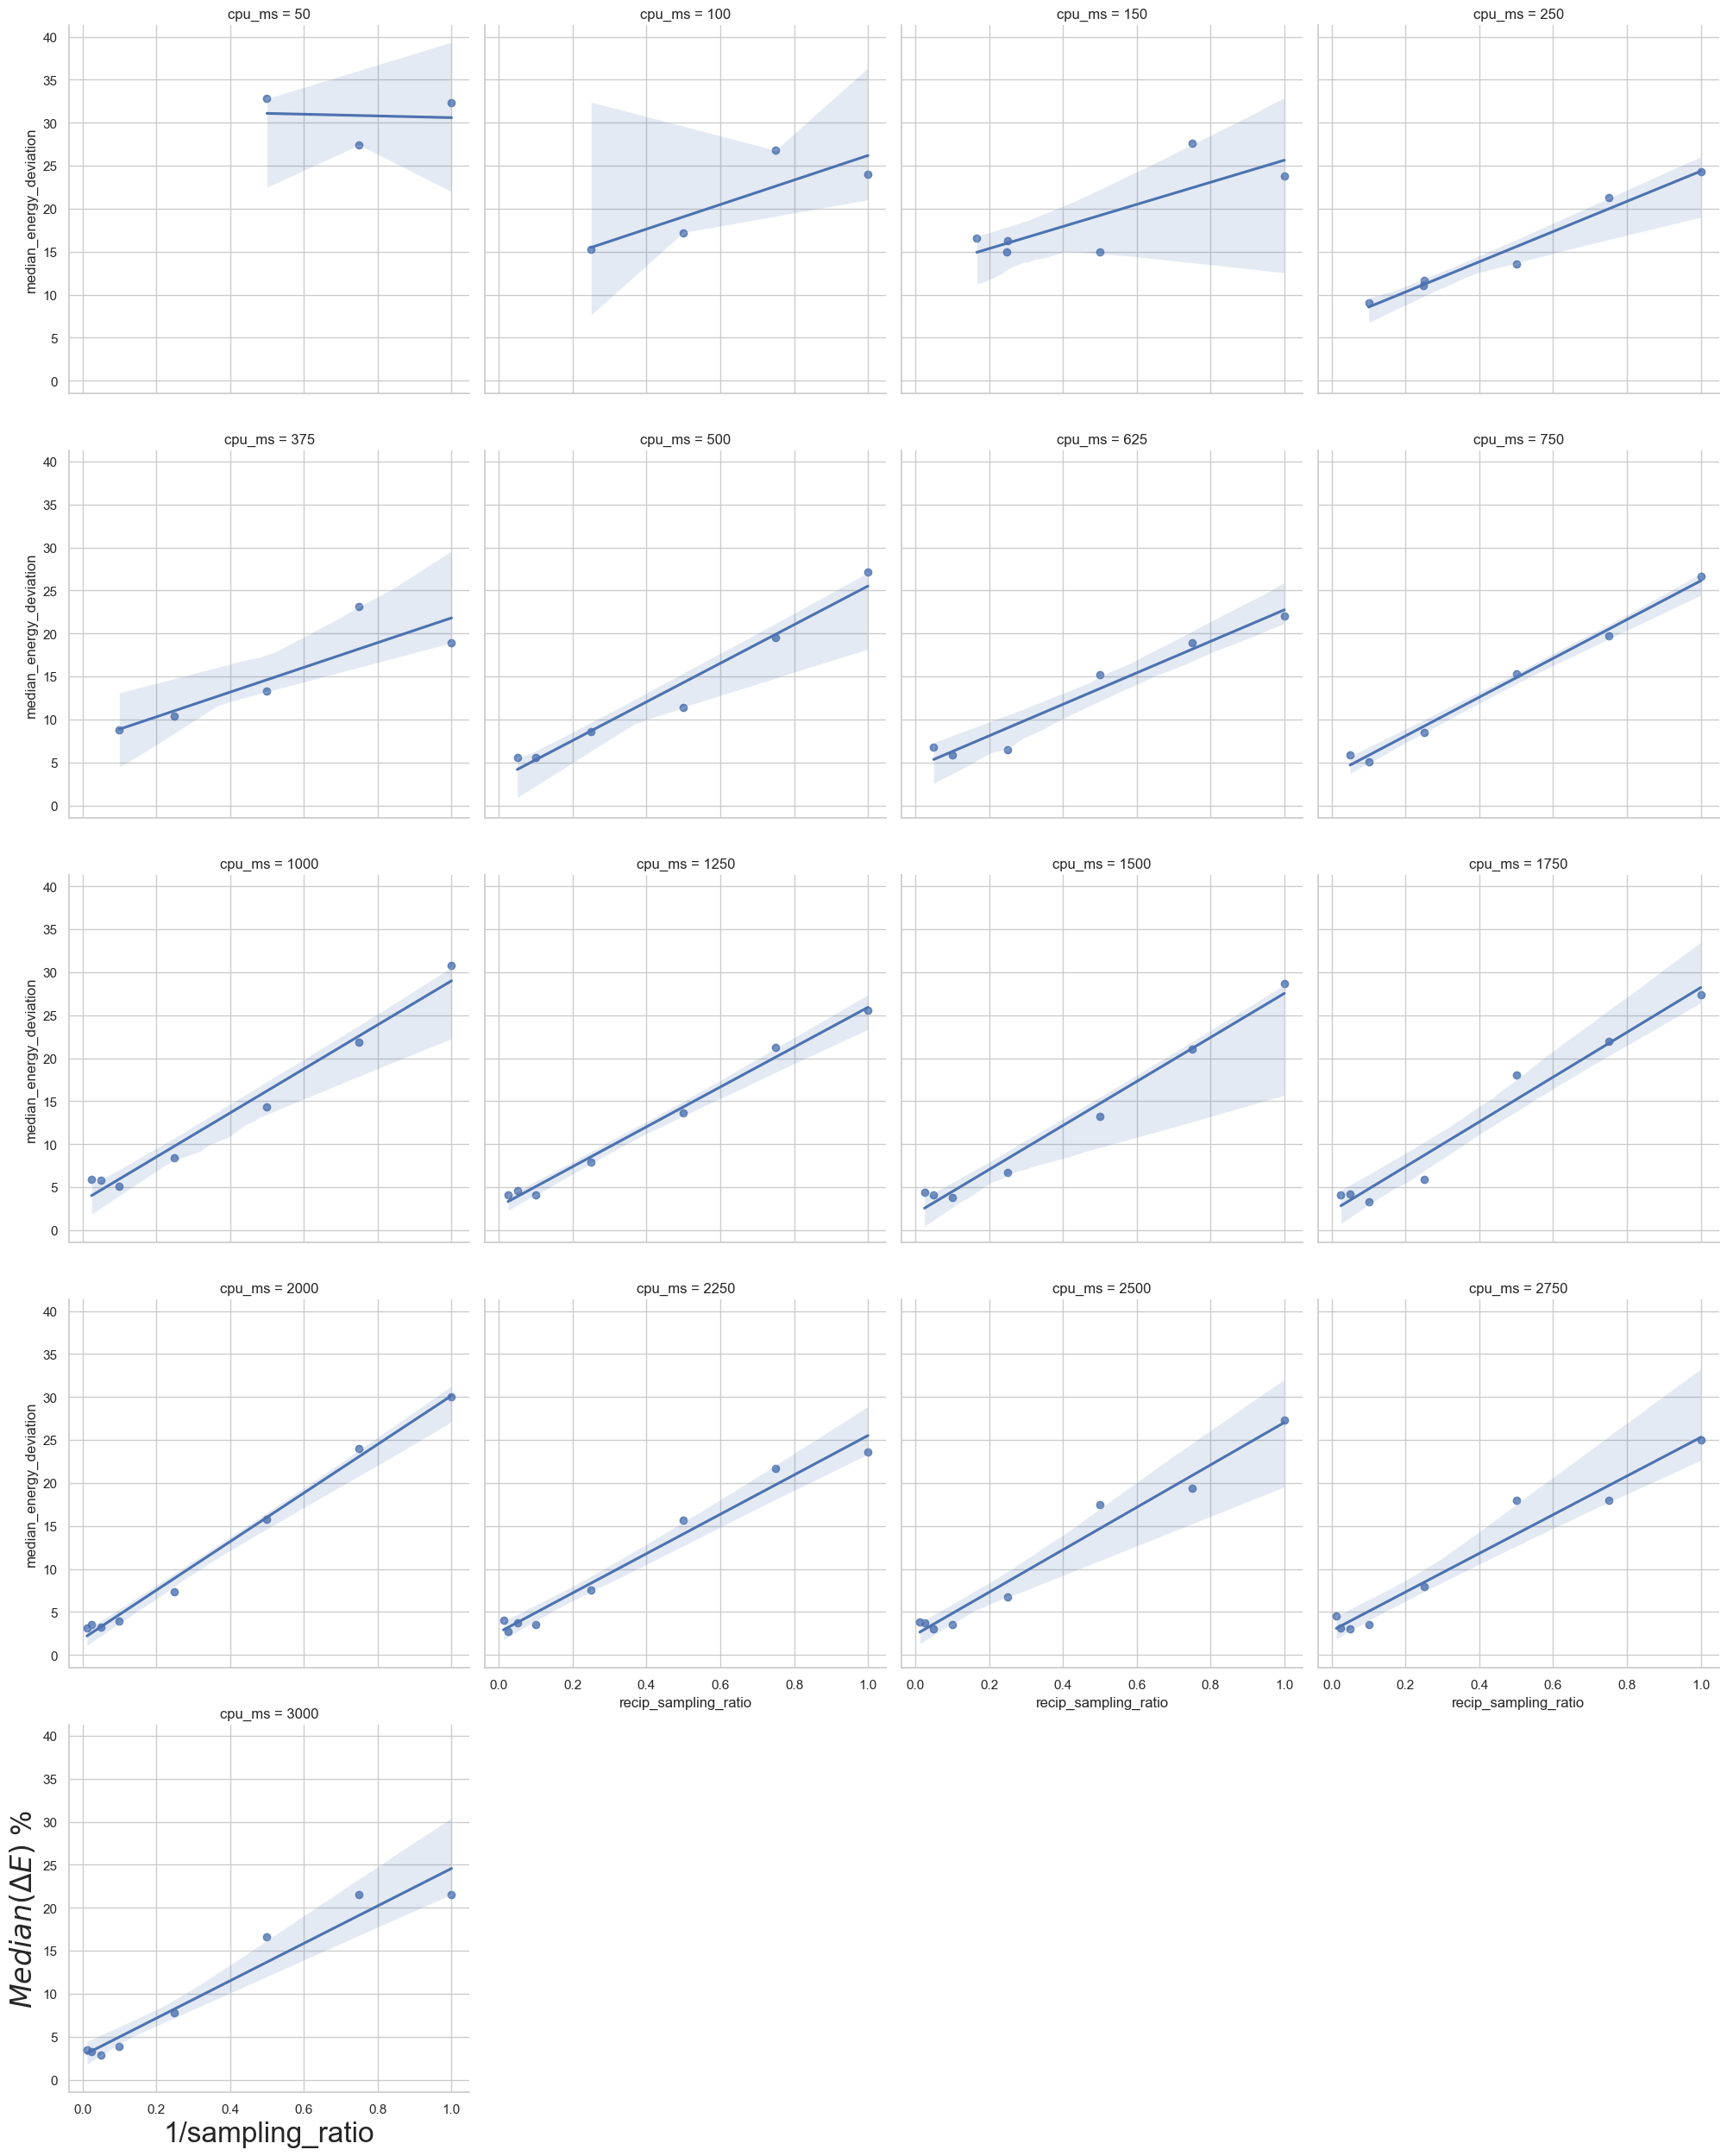

In [26]:
plt.figure(figsize=(10,10))
sns.lmplot(data=df_median_dev_1000, x='recip_sampling_ratio', y='median_energy_deviation', col='cpu_ms', col_wrap=4, palette='tab10', markers='o', ci=95)
plt.xlabel("1/sampling_ratio", fontsize=fs)
plt.ylabel(r'$Median ({\Delta E})$ %', fontsize=fs)

### From the "Taming Performance Variability" paper: "compute $\lfloor{\frac{n - z \sqrt{n}}{ 2}}\rfloor$ and $\lceil{1+\frac{n+z \sqrt{n}  }{2} }\rceil$,where n is the number of elements in X, and z is the standard score (or z-score). z depends only on the desired confidence level, and is 1.96 for the commonly-used level of $\alpha = 95\\\%$. These two numbers are then used as indexes into the sorted X: the values at those locations are the top and the bottom bounds of the CI. Note that one of these numbers will be larger than the median (at index n/2) and the other will be smaller, and they will not necessarily be symmetric around the median. These bounds tend to get tighter—to approach the sample mean—with more repetitions. Typically, we are concerned with the relative difference r% between the CI bounds and the mean."

#### In this data there are some with a sampling ratio very close to but not exactly 4. Going to merge those with values close to 4 with those with exactly 4

In [31]:

df_filtered_1000.query('(sampling_ratio > 4) & (sampling_ratio < 5)').sampling_ratio

12       4.054054
20       4.054054
48       4.054054
53       4.054054
57       4.032258
           ...   
44974    4.054054
44992    4.054054
45033    4.032258
45063    4.054054
45091    4.054054
Name: sampling_ratio, Length: 1620, dtype: float64

In [32]:
df_filtered_1000_fixed = df_filtered_1000.copy()

In [33]:
# df['gender'] = df['gender'].apply(lambda x: 0 if x == 'female' else x)

df_filtered_1000_fixed['sampling_ratio'] = df_filtered_1000_fixed['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)

# update recip ratio
df_filtered_1000_fixed['recip_sampling_ratio'] = 1 / df_filtered_1000_fixed.sampling_ratio

# check it
df_filtered_1000_fixed.query('(sampling_ratio == 4) & (sampling_ratio < 5)').sampling_ratio.count()
df_filtered_1000_fixed.groupby('sampling_ratio').size(), df_filtered_1000_fixed.groupby('recip_sampling_ratio').size()

(sampling_ratio
 1.000000     6200
 1.333333     6200
 2.000000     6200
 4.000000     5200
 6.000000     1000
 10.000000    3200
 20.000000    2100
 40.000000    1800
 80.000000     500
 dtype: int64,
 recip_sampling_ratio
 0.012500     500
 0.025000    1800
 0.050000    2100
 0.100000    3200
 0.166667    1000
 0.250000    5200
 0.500000    6200
 0.750000    6200
 1.000000    6200
 dtype: int64)

#### Looks cleaned up - moving on to modeling

#### Rebuild dataframe of median accuracy values

In [34]:
df_median_dev_1000 = df_filtered_1000_fixed.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
#df_std_dev_1000 = df_filtered_1000.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).std()

df_median_dev_1000 = df_median_dev_1000.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
#df_mean_dev_1000['std_energy_deviation'] = df_std_dev_1000['energy_deviation_pct_abs']

#df_mean_dev_1000['conf_int_95'] = 1.96 * df_mean_dev_1000.std_energy_deviation / np.sqrt(100)
df_median_dev_1000['recip_sampling_ratio'] = 1 / df_median_dev_1000.sampling_ratio
df_median_dev_1000

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio
0,50,1.000000,32.310898,1.0000
1,50,1.333333,27.400104,0.7500
2,50,2.000000,32.807953,0.5000
3,100,1.000000,24.012295,1.0000
4,100,1.333333,26.807242,0.7500
...,...,...,...,...
103,3000,4.000000,7.814742,0.2500
104,3000,10.000000,3.853761,0.1000
105,3000,20.000000,2.849205,0.0500
106,3000,40.000000,3.234945,0.0250


#### Build confidence intervals on accuracy per span length and reciprocal sampling ratio

In [36]:
span_lengths = np.unique(df_filtered_1000_fixed.cpu_ms)
span_lengths

array([  50,  100,  150,  250,  375,  500,  625,  750, 1000, 1250, 1500,
       1750, 2000, 2250, 2500, 2750, 3000])

In [40]:
# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','recip_sampling_ratio','delta_e_upper_ci','delta_e_lower_ci'])

for span_ms in span_lengths:
    ratio_list = np.unique(df_filtered_1000_fixed.query('cpu_ms == @span_ms').recip_sampling_ratio)
    for ratio in ratio_list:
        the_n = df_filtered_1000_fixed.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)').shape[0]
        lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
        upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
        acc_eng = df_filtered_1000_fixed.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)')['energy_deviation_pct_abs']
        acc_eng_sorted = np.sort(acc_eng)
        acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
        acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
        temp_df.loc[len(temp_df.index)] = [the_n, span_ms, ratio, acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
        

,n,cpu_ms,recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,1000.0,50.0,0.50,34.862136,31.515843
1,1000.0,50.0,0.75,29.737155,25.596970
2,1000.0,50.0,1.00,34.930428,30.041363
3,1000.0,100.0,0.25,16.908764,14.099121
4,1000.0,100.0,0.50,18.284894,15.973499
...,...,...,...,...,...
103,100.0,3000.0,0.10,4.972663,2.779900
104,100.0,3000.0,0.25,9.924824,6.785519
105,100.0,3000.0,0.50,22.641597,14.734863
106,100.0,3000.0,0.75,27.458456,18.144331


### add columns with CI values for that cpu_ms and sampling ratio

In [41]:
cpu_ms_vals = np.unique(df_median_dev_1000['cpu_ms'])
#ratio_vals = np.unique(df_median_dev_1000['recip_sampling_ratio'])

for i in cpu_ms_vals:
    ratio_vals = np.unique(df_median_dev_1000.query('cpu_ms == @i').recip_sampling_ratio)    
    for j in ratio_vals:
        # copy in CI values
        df_median_dev_1000.loc[(df_median_dev_1000['cpu_ms'] == i) & (df_median_dev_1000['recip_sampling_ratio'] == j), 
            'delta_e_upper_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_upper_ci.values[0]
        df_median_dev_1000.loc[(df_median_dev_1000['cpu_ms'] == i) & (df_median_dev_1000['recip_sampling_ratio'] == j), 
            'delta_e_lower_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_lower_ci.values[0]

df_median_dev_1000.head(10)

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,50,1.000000,32.310898,1.00,34.930428,30.041363
1,50,1.333333,27.400104,0.75,29.737155,25.596970
2,50,2.000000,32.807953,0.50,34.862136,31.515843
3,100,1.000000,24.012295,1.00,27.147338,22.278924
4,100,1.333333,26.807242,0.75,28.931794,25.537830
5,100,2.000000,17.224892,0.50,18.284894,15.973499
6,100,4.000000,15.325322,0.25,16.908764,14.099121
7,150,1.000000,23.782289,1.00,25.603385,22.165877
8,150,1.333333,27.615014,0.75,29.052738,25.865547
9,150,2.000000,14.991515,0.50,16.200643,14.222031


### Now add OLS model and check fits

### Model with only recip sampling ratio to avoid multicollinearity

In [43]:
df_median_dev_1000.columns

Index(['cpu_ms', 'sampling_ratio', 'median_energy_deviation',
       'recip_sampling_ratio', 'delta_e_upper_ci', 'delta_e_lower_ci'],
      dtype='object')

#### Only considering span lengths <= 1000 ms for now

In [44]:
# define x & y
df_sub1000 = df_median_dev_1000.query("cpu_ms <= 1000.0")
X = df_sub1000.drop(['cpu_ms','sampling_ratio', 'median_energy_deviation',
       'delta_e_upper_ci', 'delta_e_lower_ci'], axis=1)
y = df_sub1000['median_energy_deviation']


#### do a train/test split of 80/20 so I can determine RMSE and $R^{2}$ on out-of-sample data

In [50]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

#### build model and check coefficients

In [51]:
mlr = LinearRegression()  
mlr.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(21.14295167122516))] 
 Intercept:  5.788255553942857


In [52]:
# make predictions based on test data
y_pred = mlr.predict(x_test)

In [53]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  1.5712295985171327
The R^2 is:  0.9553830451336387


#### Low RMSE and an $R^{2} = 0.96$ is excellent

#### Plot some of the fits and original data

#### make function for using regression model in plot

In [54]:
# make function for using regression model
def reg_model(recip_sampling_ratio):
    return (mlr.intercept_ + mlr.coef_[0]*recip_sampling_ratio)

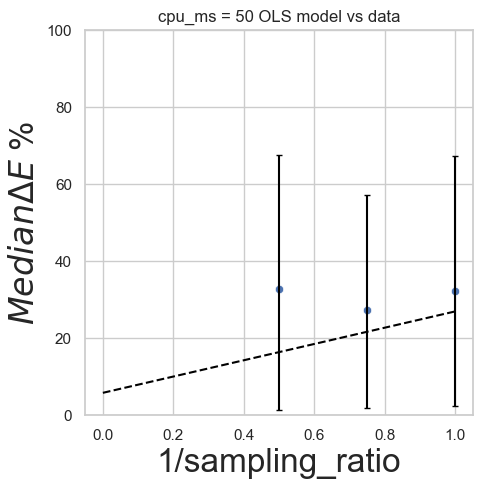

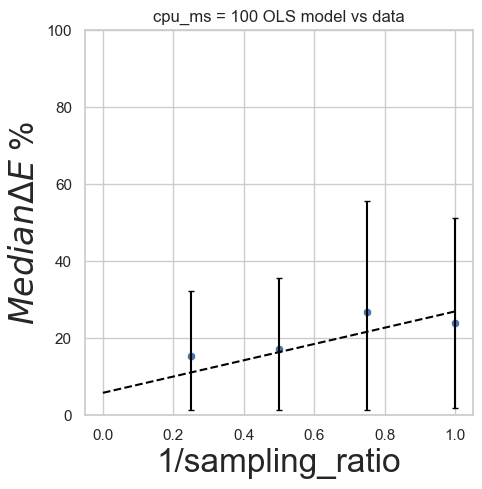

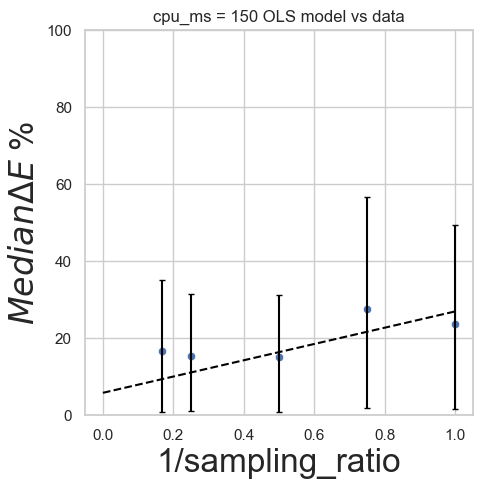

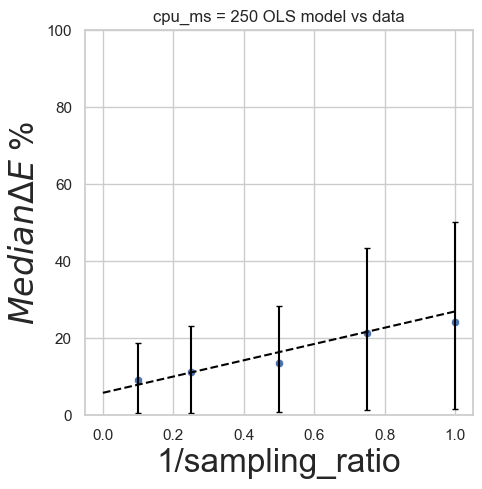

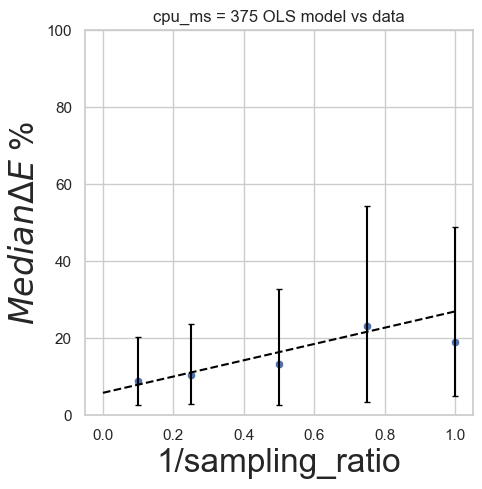

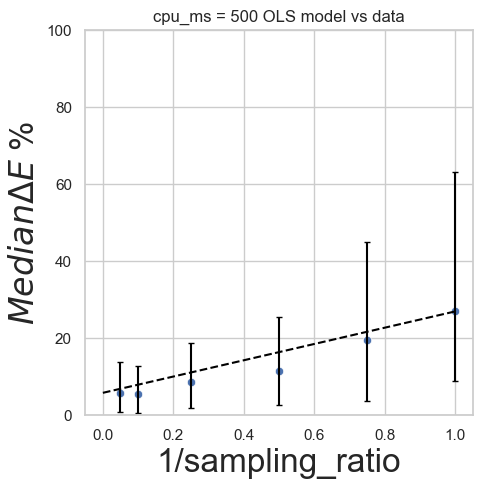

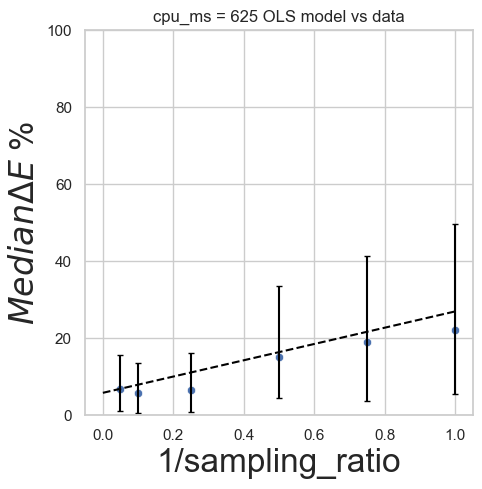

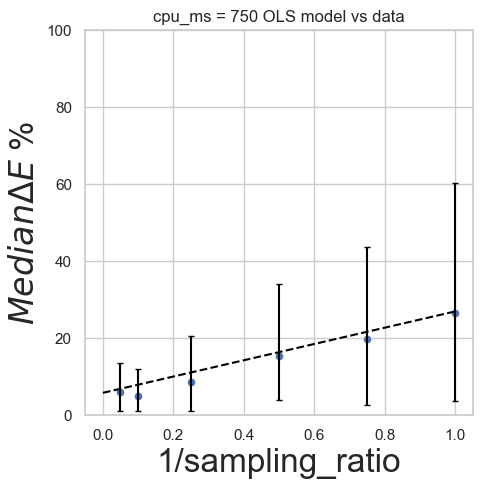

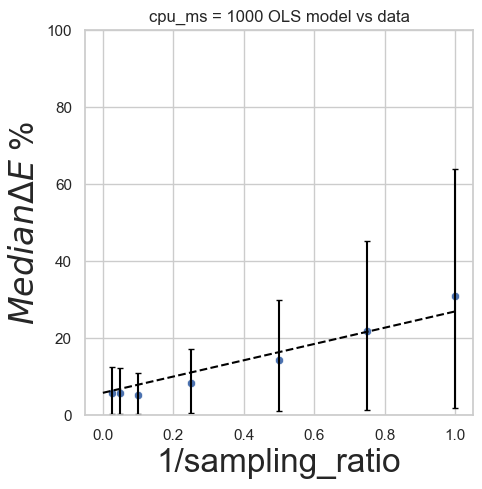

In [55]:
span_lengths = np.unique(df_median_dev_1000.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    tmp_df = df_median_dev_1000.drop(['sampling_ratio'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=tmp_df, x=tmp_df['recip_sampling_ratio'], y=tmp_df['median_energy_deviation'])
    plt.errorbar(tmp_df['recip_sampling_ratio'], tmp_df['median_energy_deviation'], yerr=[tmp_df['delta_e_lower_ci'],tmp_df['delta_e_upper_ci'] ], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, reg_model(x_vals), color="black", linestyle="--")
    plt.ylim(0,100)
    plt.xlabel("1/sampling_ratio", fontsize=fs)
    plt.ylabel(r'$Median \Delta E$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" OLS model vs data")
    plt.show()

In [56]:
print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(21.14295167122516))] 
 Intercept:  5.788255553942857


### OLS model: $ Median Accuracy (\\\%) = 21.14*\frac{1}{sampling\\\_ratio} + 5.79$
### where $sampling\\\_ratio = \frac{span_{ms}}{measurement\\\_interval_{ms}}$

## How does model change based on N? How does distribution change?

In [57]:
df_filtered_1000_fixed

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,recip_sampling_ratio
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00,3.792336,-0.381900,-10.070296,20.000000,10.070296,0.050
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00,0.455825,-0.424935,-93.223488,1.000000,93.223488,1.000
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00,0.455825,0.014090,3.090992,2.000000,3.090992,0.500
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00,7.795812,0.001889,0.024225,40.000000,0.024225,0.025
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75,10.669263,-0.099719,-0.934643,40.000000,0.934643,0.025
...,...,...,...,...,...,...,...,...,...,...
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.00,0.844799,-0.052722,-6.240774,2.000000,6.240774,0.500
45093,7b922ca3da3a636784c4c09e3784c031,9.031293,3000,2250.00,11.760279,2.728986,23.205113,1.333333,23.205113,0.750
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.00,0.128859,0.031773,24.657183,2.000000,24.657183,0.500
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.00,0.285802,0.120961,42.323256,1.333333,42.323256,0.750


In [59]:
df_filtered_1000_fixed.columns

Index(['trace_id', 'energy_joules_span', 'cpu_ms', 'active_interval_ms',
       'median_energy_cpu_ms', 'energy_devation', 'energy_deviation_pct',
       'sampling_ratio', 'energy_deviation_pct_abs', 'recip_sampling_ratio'],
      dtype='object')

#### Filter to the columns we need for gathering samples

In [60]:
df_sampling = df_filtered_1000_fixed.drop([ 'median_energy_cpu_ms', 'energy_devation', 'energy_deviation_pct',
       'sampling_ratio', 'energy_deviation_pct_abs', 'recip_sampling_ratio'], axis=1)
df_sampling.head(10)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.00
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.00
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.00
3,abc243f0e8195d4e5ef242db69fbe9a0,7.793923,2000,50.00
5,afde2ce03d6cc9f302ef16417f0f2e8b,10.768982,2750,68.75
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.00
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.00
9,9ad937051ed5fb795c71388b740c224e,0.334675,100,25.00
10,53ce784698112331713b74d2beee804a,0.444463,100,50.00
11,99648071e9c6152e9efb11bf8f8520b2,0.521254,150,25.00


#### generate n=100 sample for each cpu_ms in [100,150,250,500,1000]

In [61]:
df_sampling_50_1000 = df_sampling.query('cpu_ms <= 1000')
df_sampling_50_1000

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
0,774fea4ae5b4d969b4bf596c6eaf4af0,4.174236,1000,50.0
1,bd22803a5ff6bc7895132e7890138cae,0.880760,150,150.0
2,0b2f77748f51ba2d3f4ef632a9365ad3,0.441735,150,75.0
6,02054895ef342c9c3f395ac401485ac1,0.385348,100,25.0
7,63590d0b5518fb051ea292ceda74ace9,0.472778,100,25.0
...,...,...,...,...
45091,b3e4f8f74554920eceaddfaa6e651a4d,0.418251,150,37.0
45092,4abf6971cf4256a6028a7d6667746a23,0.897521,250,125.0
45094,8b6158e90e349f6a6bb9812d4d86da47,0.097086,50,25.0
45095,205b5eb1ff519133eeb6a2a0c1713c7d,0.164841,100,75.0


In [63]:
df_sample_100 = df_sampling_50_1000.query('cpu_ms == 100').sample(n=100, random_state=47)
df_sample_150 = df_sampling_50_1000.query('cpu_ms == 150').sample(n=100, random_state=47)
df_sample_250 = df_sampling_50_1000.query('cpu_ms == 250').sample(n=100, random_state=47)
df_sample_500 = df_sampling_50_1000.query('cpu_ms == 500').sample(n=100, random_state=47)
df_sample_1000 = df_sampling_50_1000.query('cpu_ms == 1000').sample(n=100, random_state=47)
df_sample_100

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
18280,7c574790b36b0041518ef59a0f66df57,0.351303,100,75.0
7894,b254232dbd4658b9e66e77fa6b4139d9,0.297488,100,100.0
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.224045,100,50.0
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.328348,100,100.0
25608,92e157a233fb343f7416955f7c511137,0.292961,100,100.0
...,...,...,...,...
9238,b67a9f296338ef901f3d8d96330e4dce,0.245324,100,50.0
15403,5fe5b1b7bc9f9189a54c7bf103ae02c9,0.273444,100,100.0
2485,3829a9ab5027276bb7b09785a2832b09,0.188406,100,75.0
18454,547b9558662192b30c0e4b962fba0579,0.472333,100,25.0


#### compare distributions with those from full dataset with n=1000 per cpu_ms

In [64]:
df_100 = df_sampling_50_1000.query('cpu_ms == 100')
df_150 = df_sampling_50_1000.query('cpu_ms == 150')
df_250 = df_sampling_50_1000.query('cpu_ms == 250')
df_500 = df_sampling_50_1000.query('cpu_ms == 500')
df_1000 = df_sampling_50_1000.query('cpu_ms == 1000')

In [78]:
# got this from https://www.geeksforgeeks.org/machine-learning/kolmogorov-smirnov-test-ks-test/

def ks_compare_dist(sample1, sample2):
    ks_statistic, p_value = ks_2samp(sample1, sample2, alternative='two-sided', mode='auto')
    alpha = 0.05
    
    print(f"KS Statistic: {ks_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < alpha:
        print("Reject the null hypothesis: The two samples come from different distributions.")
    else:
        print("Fail to reject the null hypothesis: No significant distributional difference detected.")
    
    
    plt.figure(figsize=(8, 5))
    plt.hist(sample1, bins=25, density=True, alpha=0.6, label="Sample 1")
    plt.hist(sample2, bins=25, density=True, alpha=0.6, label="Sample 2")
    plt.title("Two-Sample Kolmogorov-Smirnov Test")
    plt.xlabel("Energy")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

KS Statistic: 0.1017
P-value: 0.2483
Fail to reject the null hypothesis: No significant distributional difference detected.


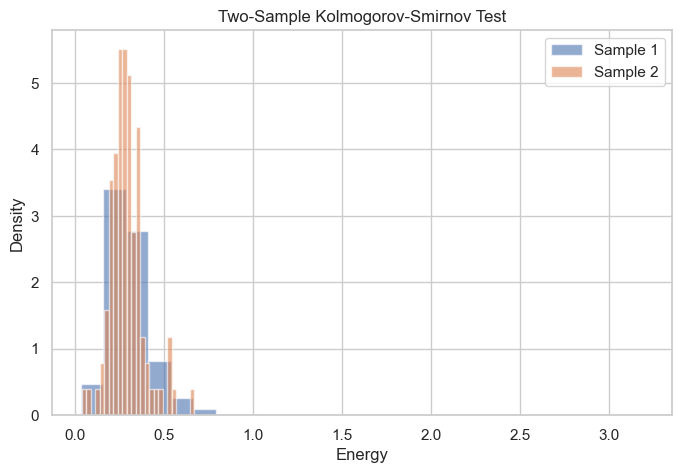

In [79]:
ks_compare_dist(df_100.energy_joules_span, df_sample_100.energy_joules_span)

KS Statistic: 0.0928
P-value: 0.3467
Fail to reject the null hypothesis: No significant distributional difference detected.


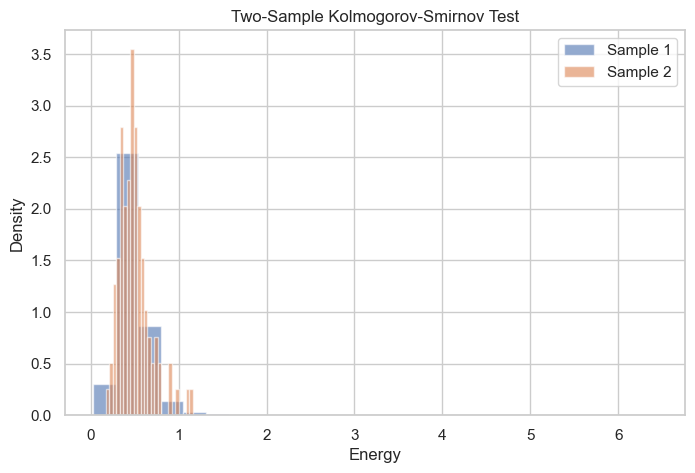

In [80]:
ks_compare_dist(df_150.energy_joules_span, df_sample_150.energy_joules_span)

KS Statistic: 0.0822
P-value: 0.4970
Fail to reject the null hypothesis: No significant distributional difference detected.


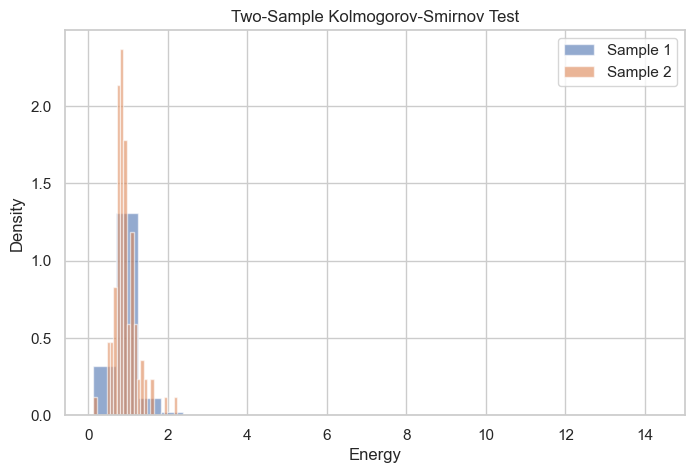

In [81]:
ks_compare_dist(df_250.energy_joules_span, df_sample_250.energy_joules_span)

KS Statistic: 0.1133
P-value: 0.2094
Fail to reject the null hypothesis: No significant distributional difference detected.


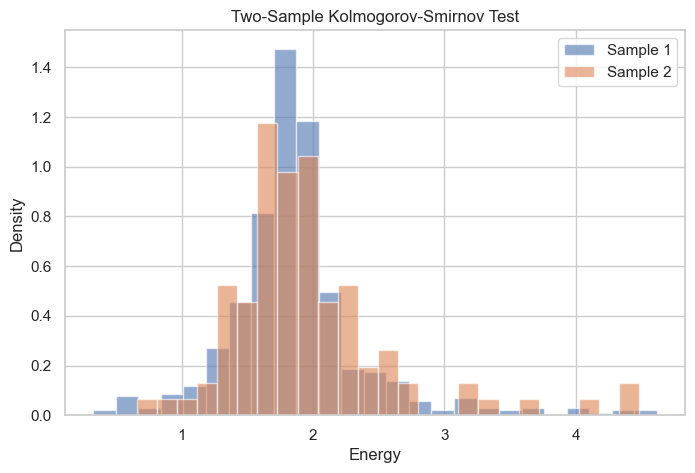

In [82]:
ks_compare_dist(df_500.energy_joules_span, df_sample_500.energy_joules_span)

KS Statistic: 0.1040
P-value: 0.2212
Fail to reject the null hypothesis: No significant distributional difference detected.


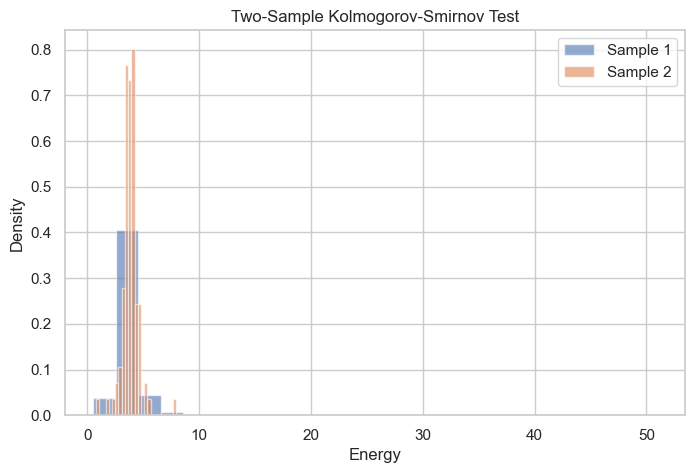

In [83]:
ks_compare_dist(df_1000.energy_joules_span, df_sample_1000.energy_joules_span)

#### Result: n=100 distributions same as n=1000

#### for cpu_ms = 100ms loop through sample sizes and do this same test


Sample size = 100
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.27837349999999983
KS Statistic: 0.1017
P-value: 0.2483
Fail to reject the null hypothesis: No significant distributional difference detected.


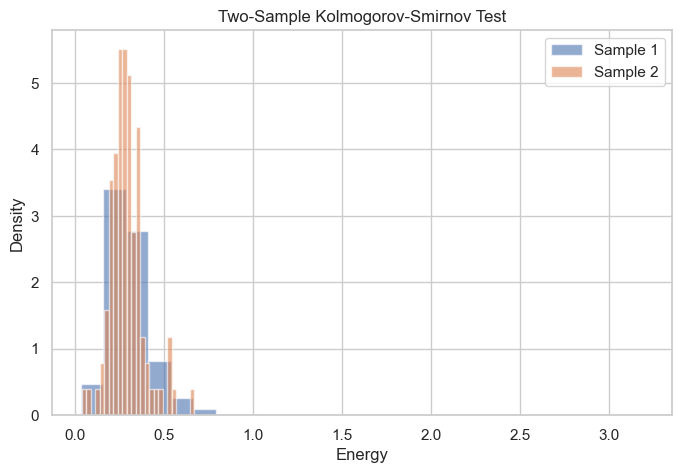


Sample size = 90
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.2774334999999999
KS Statistic: 0.1011
P-value: 0.3085
Fail to reject the null hypothesis: No significant distributional difference detected.


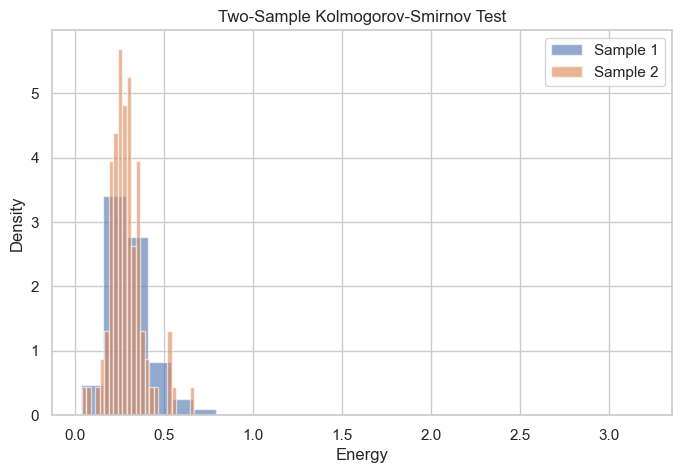


Sample size = 80
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.2790164999999998
KS Statistic: 0.1022
P-value: 0.3616
Fail to reject the null hypothesis: No significant distributional difference detected.


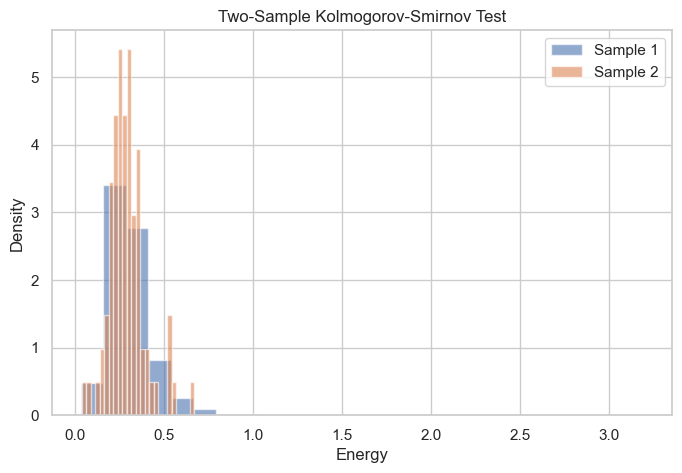


Sample size = 70
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.27959500000000026
KS Statistic: 0.1046
P-value: 0.4105
Fail to reject the null hypothesis: No significant distributional difference detected.


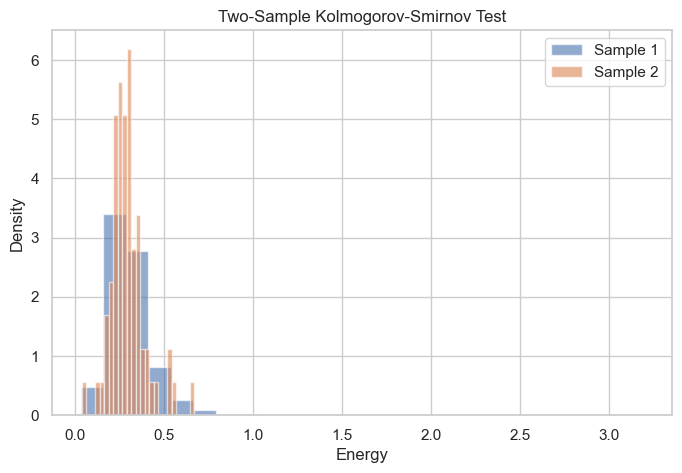


Sample size = 60
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.2732815000000002
KS Statistic: 0.1143
P-value: 0.3927
Fail to reject the null hypothesis: No significant distributional difference detected.


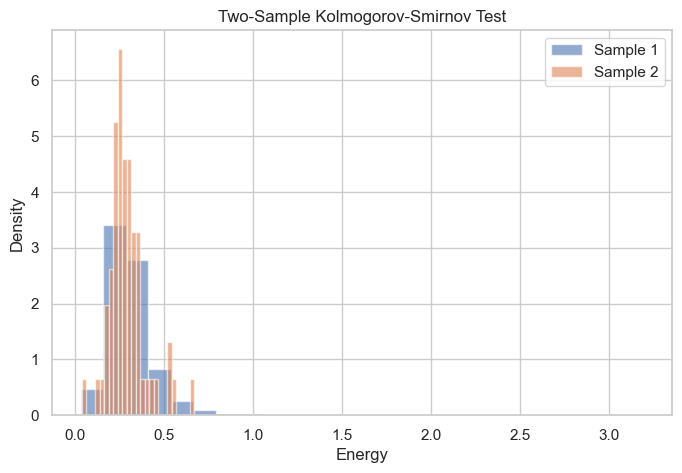


Sample size = 50
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.27616699999999994
KS Statistic: 0.1598
P-value: 0.1444
Fail to reject the null hypothesis: No significant distributional difference detected.


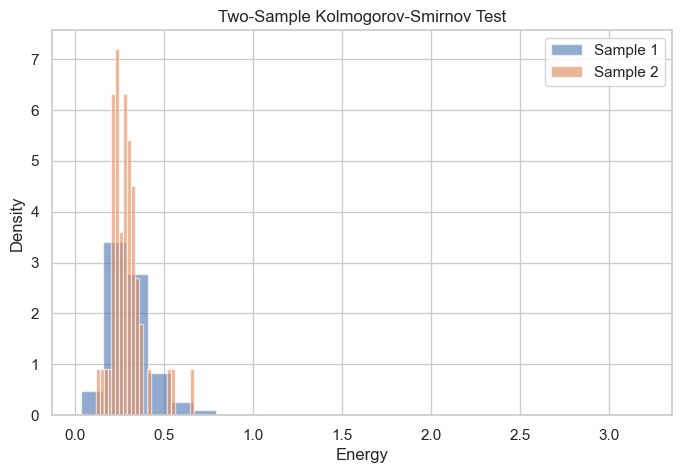


Sample size = 40
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.27959500000000026
KS Statistic: 0.1398
P-value: 0.3867
Fail to reject the null hypothesis: No significant distributional difference detected.


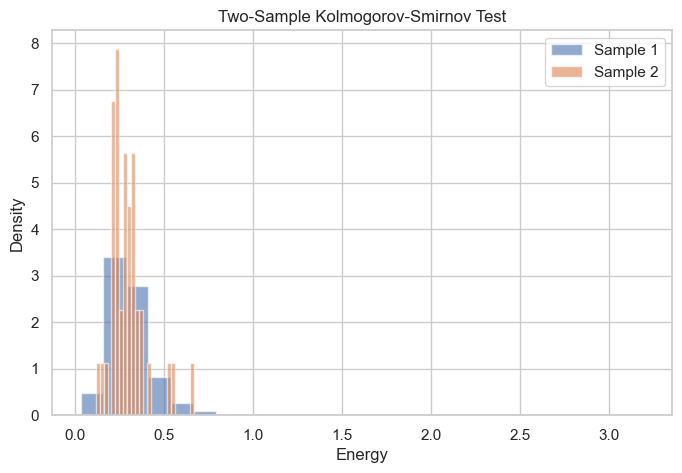


Sample size = 30
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.2790164999999998
KS Statistic: 0.2064
P-value: 0.1369
Fail to reject the null hypothesis: No significant distributional difference detected.


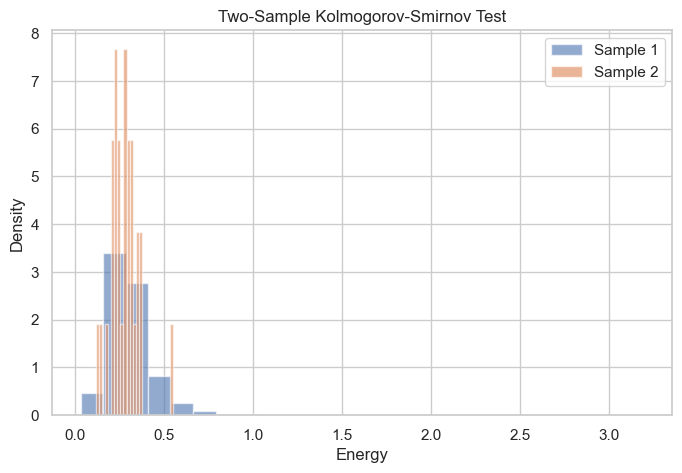


Sample size = 20
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.28126850000000025
KS Statistic: 0.2427
P-value: 0.1621
Fail to reject the null hypothesis: No significant distributional difference detected.


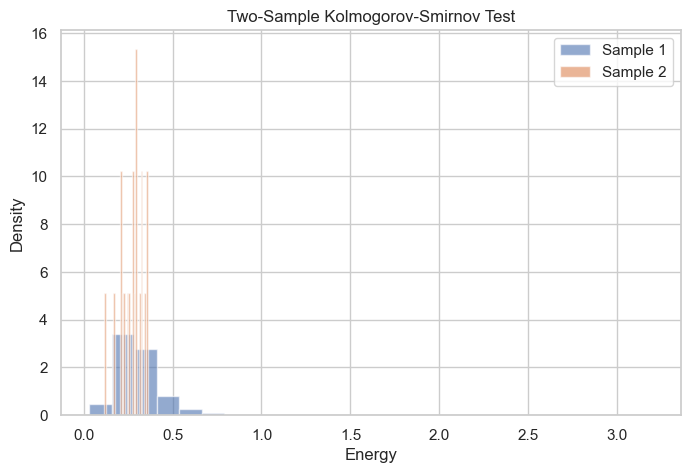


Sample size = 10
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.27648
KS Statistic: 0.2637
P-value: 0.4193
Fail to reject the null hypothesis: No significant distributional difference detected.


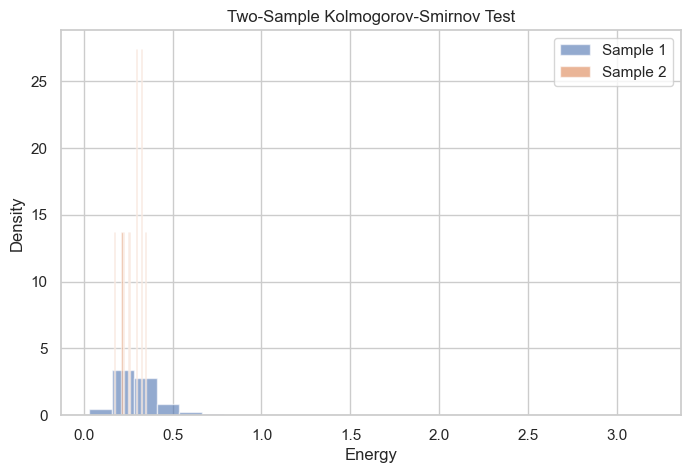

In [84]:
# try sample sizes from 100 to 10
for i in np.arange(100,0,-10):
    test_sample = df_sampling_50_1000.query('cpu_ms == 100').sample(n=i, random_state=47)
    print("\nSample size = "+str(i))
    print("Full Data Median E = "+str(np.median(df_100.energy_joules_span)))
    print("Full Data Median E = "+str(np.median(test_sample.energy_joules_span)))
    ks_compare_dist(df_100.energy_joules_span, test_sample.energy_joules_span)

#### ! Wait we only need 10 samples?

#### multiply E in the small sample by a factor and test again, n=10


Sample size = 10
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.38707199999999997
KS Statistic: 0.4645
P-value: 0.0172
Reject the null hypothesis: The two samples come from different distributions.


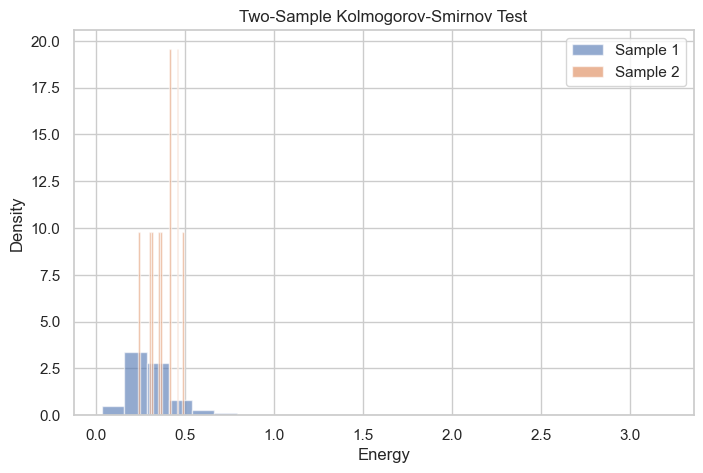

In [95]:
test_sample = df_sampling_50_1000.query('cpu_ms == 100').sample(n=10, random_state=47)
test_sample['energy_joules_span'] = test_sample.energy_joules_span * 1.4
print("\nSample size = "+str(i))
print("Full Data Median E = "+str(np.median(df_100.energy_joules_span)))
print("Full Data Median E = "+str(np.median(test_sample.energy_joules_span)))
ks_compare_dist(df_100.energy_joules_span, test_sample.energy_joules_span)

#### multiply E in the small sample by a factor and test again, n=50


Sample size = 1000
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.3866337999999999
KS Statistic: 0.4627
P-value: 0.0000
Reject the null hypothesis: The two samples come from different distributions.


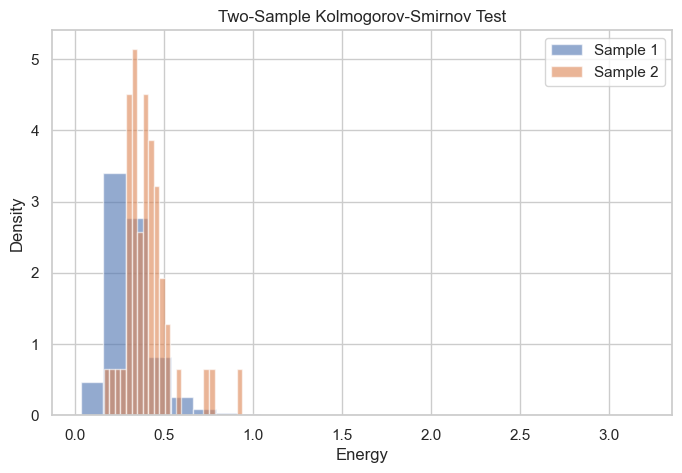

In [355]:
test_sample = df_sampling_50_1000.query('cpu_ms == 100').sample(n=50, random_state=47)
test_sample['energy_joules_span'] = test_sample.energy_joules_span * 1.4
print("\nSample size = "+str(i))
print("Full Data Median E = "+str(np.median(df_100.energy_joules_span)))
print("Full Data Median E = "+str(np.median(test_sample.energy_joules_span)))
ks_compare_dist(df_100.energy_joules_span, test_sample.energy_joules_span)

In [167]:
# test_sample = df_sampling_50_1000.query('cpu_ms == 100').sample(n=10, random_state=47).energy_joules_span
# randoms = np.random.rand(10)*2.0
# print(test_sample)
# np.multiply(test_sample, randoms)

#### multiply E's by random number from 0 - 2 in the small sample and test again


Sample size = 1000
Full Data Median E = 0.28580150000000004
Full Data Median E = 0.1746915678540594
KS Statistic: 0.4825
P-value: 0.0117
Reject the null hypothesis: The two samples come from different distributions.


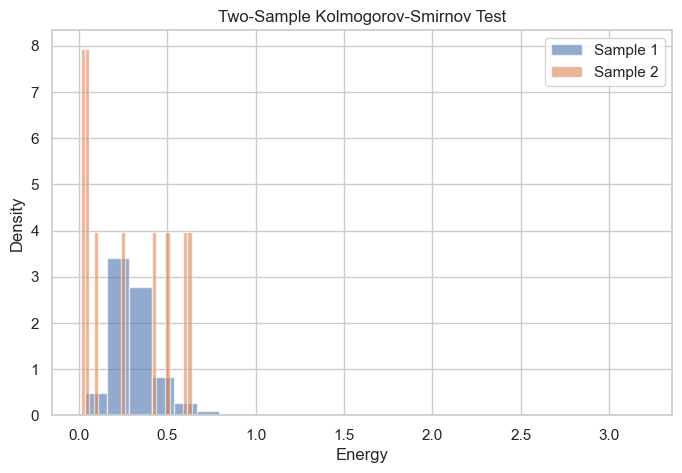

In [177]:
test_sample = df_sampling_50_1000.query('cpu_ms == 100').sample(n=10, random_state=47)
randoms = np.random.rand(10)*2.0
test_sample['energy_joules_span'] = np.multiply(test_sample.energy_joules_span, randoms)
print("\nSample size = "+str(i))
print("Full Data Median E = "+str(np.median(df_100.energy_joules_span)))
print("Full Data Median E = "+str(np.median(test_sample.energy_joules_span)))
ks_compare_dist(df_100.energy_joules_span, test_sample.energy_joules_span)

#### Conf Int on energy per span (ignoring sampling rate)

In [ ]:
span_lengths = np.unique(df_n_100.cpu_ms)

# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','recip_sampling_ratio','delta_e_upper_ci','delta_e_lower_ci'])

for span_ms in span_lengths:
    ratio_list = np.unique(df_n_100.query('cpu_ms == @span_ms').recip_sampling_ratio)
    for ratio in ratio_list:
        the_n = df_n_100.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)').shape[0]
        lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
        upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
        acc_eng = df_n_100.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)')['energy_deviation_pct_abs']
        acc_eng_sorted = np.sort(acc_eng)
        acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
        acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
        temp_df.loc[len(temp_df.index)] = [the_n, span_ms, ratio, acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
 

## K-S test seems good for deciding the distribution is different
## what about a model based on n=100 per cpu_ms?

In [128]:
df_n_100 = pd.concat([df_sample_100, df_sample_150, df_sample_250, df_sample_500, df_sample_1000])
df_n_100

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
18280,7c574790b36b0041518ef59a0f66df57,0.351303,100,75.0
7894,b254232dbd4658b9e66e77fa6b4139d9,0.297488,100,100.0
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.224045,100,50.0
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.328348,100,100.0
25608,92e157a233fb343f7416955f7c511137,0.292961,100,100.0
...,...,...,...,...
21695,d50b655f75f48101a446693534e087cc,4.164909,1000,50.0
38747,313a66cd4fe84c7297bdfeeb00495859,3.693364,1000,50.0
1850,feaa2f3b22d65fe1563cb822c7b40bf8,3.987485,1000,100.0
1317,91b880379e797de8ec5912e7c1377fbb,3.765539,1000,500.0


### Get Median E for each cpu_ms

In [129]:
df_median_e_cpu_sample = df_n_100[['energy_joules_span','cpu_ms']].copy()
df_median_e_cpu_sample = df_median_e_cpu_sample.groupby(['cpu_ms'], as_index=False).median()
df_median_e_cpu_sample

,cpu_ms,energy_joules_span
0,100,0.278373
1,150,0.473903
2,250,0.860685
3,500,1.830505
4,1000,3.788496


### add column with median energy for that cpu_ms to each trace_id

In [130]:
cpu_ms_vals = np.unique(df_n_100['cpu_ms'])
for i in cpu_ms_vals:
    df_n_100.loc[df['cpu_ms'] == i, 'median_energy_cpu_ms'] = df_median_e_cpu_sample[df_median_e_cpu_sample['cpu_ms'] == i].energy_joules_span.values[0]

df_n_100.head(20)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms
18280,7c574790b36b0041518ef59a0f66df57,0.351303,100,75.0,0.278373
7894,b254232dbd4658b9e66e77fa6b4139d9,0.297488,100,100.0,0.278373
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.224045,100,50.0,0.278373
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.328348,100,100.0,0.278373
25608,92e157a233fb343f7416955f7c511137,0.292961,100,100.0,0.278373
31513,b57c891dbd5b6eeb5e2d3235a8b4a746,0.214182,100,100.0,0.278373
7402,9cc5d5dc91f491e705e07563de1da61a,0.323592,100,75.0,0.278373
29882,710c51bf52b3cbbd65f944b3244b75b0,0.250405,100,100.0,0.278373
6338,f6c432ee7d11ac90047cd85fb0e8e6e0,0.168978,100,100.0,0.278373
6306,7133397e951a8e239c0ffc6e5df4bd9c,0.259999,100,50.0,0.278373


### calculate deviation per trace E from median for that cpu_ms

In [131]:
df_n_100['energy_devation'] = (df_n_100.median_energy_cpu_ms - df_n_100.energy_joules_span) 

### and add columns for % deviation from median for that cpu_ms, sampling ratio, and accuracy
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [132]:
df_n_100['energy_deviation_pct'] = 100 * df_n_100.energy_devation / df_n_100.median_energy_cpu_ms
df_n_100['sampling_ratio'] = df_n_100.cpu_ms / df_n_100.active_interval_ms
df_n_100['energy_deviation_pct_abs'] = np.abs(df_n_100.energy_deviation_pct)
df_n_100['recip_sampling_ratio'] = 1 / df_n_100.sampling_ratio

In [133]:
df_n_100

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,recip_sampling_ratio
18280,7c574790b36b0041518ef59a0f66df57,0.351303,100,75.0,0.278373,-0.072929,-26.198435,1.333333,26.198435,0.75
7894,b254232dbd4658b9e66e77fa6b4139d9,0.297488,100,100.0,0.278373,-0.019115,-6.866494,1.000000,6.866494,1.00
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.224045,100,50.0,0.278373,0.054329,19.516405,2.000000,19.516405,0.50
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.328348,100,100.0,0.278373,-0.049975,-17.952319,1.000000,17.952319,1.00
25608,92e157a233fb343f7416955f7c511137,0.292961,100,100.0,0.278373,-0.014588,-5.240262,1.000000,5.240262,1.00
...,...,...,...,...,...,...,...,...,...,...
21695,d50b655f75f48101a446693534e087cc,4.164909,1000,50.0,3.788496,-0.376413,-9.935684,20.000000,9.935684,0.05
38747,313a66cd4fe84c7297bdfeeb00495859,3.693364,1000,50.0,3.788496,0.095132,2.511076,20.000000,2.511076,0.05
1850,feaa2f3b22d65fe1563cb822c7b40bf8,3.987485,1000,100.0,3.788496,-0.198989,-5.252454,10.000000,5.252454,0.10
1317,91b880379e797de8ec5912e7c1377fbb,3.765539,1000,500.0,3.788496,0.022957,0.605966,2.000000,0.605966,0.50


In [134]:
np.unique(df_n_100.sampling_ratio)

array([ 1.        ,  1.33333333,  2.        ,  4.        ,  4.03225806,
        4.05405405,  6.        , 10.        , 20.        , 40.        ])

In [135]:
df_n_100['sampling_ratio'] = df_n_100['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)
df_n_100['recip_sampling_ratio'] = 1 / df_n_100.sampling_ratio
np.unique(df_n_100.sampling_ratio)

array([ 1.        ,  1.33333333,  2.        ,  4.        ,  6.        ,
       10.        , 20.        , 40.        ])

#### Rebuild dataframe of median accuracy values

In [136]:
df_median_n_100 = df_n_100.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
df_median_n_100 = df_median_n_10.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
df_median_n_100['recip_sampling_ratio'] = 1 / df_median_n_100.sampling_ratio
df_median_n_100

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio
0,100,1.000000,13.964332,1.000000
1,100,1.333333,25.290302,0.750000
2,100,2.000000,11.872359,0.500000
3,100,4.000000,12.556332,0.250000
4,150,1.000000,28.592590,1.000000
5,150,1.333333,33.738691,0.750000
6,150,2.000000,17.631475,0.500000
7,150,4.000000,16.595819,0.250000
8,150,6.000000,7.745475,0.166667
9,250,1.000000,22.263501,1.000000


In [178]:
df_n_100

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,recip_sampling_ratio
18280,7c574790b36b0041518ef59a0f66df57,0.351303,100,75.0,0.278373,-0.072929,-26.198435,1.333333,26.198435,0.75
7894,b254232dbd4658b9e66e77fa6b4139d9,0.297488,100,100.0,0.278373,-0.019115,-6.866494,1.000000,6.866494,1.00
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.224045,100,50.0,0.278373,0.054329,19.516405,2.000000,19.516405,0.50
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.328348,100,100.0,0.278373,-0.049975,-17.952319,1.000000,17.952319,1.00
25608,92e157a233fb343f7416955f7c511137,0.292961,100,100.0,0.278373,-0.014588,-5.240262,1.000000,5.240262,1.00
...,...,...,...,...,...,...,...,...,...,...
21695,d50b655f75f48101a446693534e087cc,4.164909,1000,50.0,3.788496,-0.376413,-9.935684,20.000000,9.935684,0.05
38747,313a66cd4fe84c7297bdfeeb00495859,3.693364,1000,50.0,3.788496,0.095132,2.511076,20.000000,2.511076,0.05
1850,feaa2f3b22d65fe1563cb822c7b40bf8,3.987485,1000,100.0,3.788496,-0.198989,-5.252454,10.000000,5.252454,0.10
1317,91b880379e797de8ec5912e7c1377fbb,3.765539,1000,500.0,3.788496,0.022957,0.605966,2.000000,0.605966,0.50


#### 95% Conf Int on energy per span (ignoring sampling rate)

In [200]:
span_lengths = np.unique(df_n_100.cpu_ms)

# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df_e = pd.DataFrame(columns=['n','cpu_ms','median_energy_cpu_ms','e_upper_ci95','e_lower_ci95'])

for span_ms in span_lengths:
    the_n = df_n_100.query('(cpu_ms == @span_ms)').shape[0]
    median_energy = df_n_100.query('(cpu_ms == @span_ms)').median_energy_cpu_ms.values[0]
    lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
    upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
    eng = df_n_100.query('(cpu_ms == @span_ms)')['energy_joules_span']
    eng_sorted = np.sort(eng)
    eng_upper_ci = eng_sorted[upper_ci_idx]
    eng_lower_ci = eng_sorted[lower_ci_idx]
    temp_df_e.loc[len(temp_df_e.index)] = [the_n, span_ms, median_energy, eng_upper_ci, eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df_e
 

,n,cpu_ms,median_energy_cpu_ms,e_upper_ci95,e_lower_ci95
0,100.0,100.0,0.278373,0.299559,0.262052
1,100.0,150.0,0.473903,0.518515,0.446326
2,100.0,250.0,0.860685,0.916894,0.823486
3,100.0,500.0,1.830505,1.932629,1.765016
4,100.0,1000.0,3.788496,3.971135,3.693364


array([ 100,  150,  250,  500, 1000])

#### 90% Conf Int on energy per span (ignoring sampling rate)

In [201]:
span_lengths = np.unique(df_n_100.cpu_ms)

# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.645


temp_df_e = pd.DataFrame(columns=['n','cpu_ms','median_energy_cpu_ms','e_upper_ci90','e_lower_ci90'])

for span_ms in span_lengths:
    the_n = df_n_100.query('(cpu_ms == @span_ms)').shape[0]
    median_energy = df_n_100.query('(cpu_ms == @span_ms)').median_energy_cpu_ms.values[0]
    lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
    upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
    eng = df_n_100.query('(cpu_ms == @span_ms)')['energy_joules_span']
    eng_sorted = np.sort(eng)
    eng_upper_ci = eng_sorted[upper_ci_idx]
    eng_lower_ci = eng_sorted[lower_ci_idx]
    temp_df_e.loc[len(temp_df_e.index)] = [the_n, span_ms, median_energy, eng_upper_ci, eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df_e
 

,n,cpu_ms,median_energy_cpu_ms,e_upper_ci90,e_lower_ci90
0,100.0,100.0,0.278373,0.298801,0.264811
1,100.0,150.0,0.473903,0.513422,0.448004
2,100.0,250.0,0.860685,0.905122,0.832932
3,100.0,500.0,1.830505,1.926451,1.769755
4,100.0,1000.0,3.788496,3.968935,3.703675


#### Build confidence intervals on accuracy per span length and reciprocal sampling ratio

In [137]:
span_lengths = np.unique(df_median_n_100.cpu_ms)
span_lengths

array([ 100,  150,  250,  500, 1000])

In [138]:
# set params for conf intervals calculation
# here using the Z-score for 95% confidence

z = 1.96


temp_df = pd.DataFrame(columns=['n','cpu_ms','recip_sampling_ratio','delta_e_upper_ci','delta_e_lower_ci'])

for span_ms in span_lengths:
    ratio_list = np.unique(df_n_100.query('cpu_ms == @span_ms').recip_sampling_ratio)
    for ratio in ratio_list:
        the_n = df_n_100.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)').shape[0]
        lower_ci_idx = int(np.floor((the_n - z*np.sqrt(the_n))/2))
        upper_ci_idx = int(np.ceil(1 + ((the_n + z*np.sqrt(the_n))/2)))
        acc_eng = df_n_100.query('(cpu_ms == @span_ms) & (recip_sampling_ratio == @ratio)')['energy_deviation_pct_abs']
        acc_eng_sorted = np.sort(acc_eng)
        acc_eng_upper_ci = acc_eng_sorted[upper_ci_idx]
        acc_eng_lower_ci = acc_eng_sorted[lower_ci_idx]
        temp_df.loc[len(temp_df.index)] = [the_n, span_ms, ratio, acc_eng_upper_ci, acc_eng_lower_ci]
        #print(the_n,span_ms,ratio,acc_eng_upper_ci,acc_eng_lower_ci)

temp_df
        

IndexError: index 7 is out of bounds for axis 0 with size 6

### *** can't build CIs with n=100 if not enough sampling_ratios

#### SKIPPED: add columns with CI values for that cpu_ms and sampling ratio

In [41]:
cpu_ms_vals = np.unique(df_median_n_100['cpu_ms'])
#ratio_vals = np.unique(df_median_dev_1000['recip_sampling_ratio'])

for i in cpu_ms_vals:
    ratio_vals = np.unique(df_median_n_100.query('cpu_ms == @i').recip_sampling_ratio)    
    for j in ratio_vals:
        # copy in CI values
        df_median_n_100.loc[(df_median_n_100['cpu_ms'] == i) & (df_median_n_100['recip_sampling_ratio'] == j), 
            'delta_e_upper_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_upper_ci.values[0]
        df_median_n_100.loc[(df_median_n_100['cpu_ms'] == i) & (df_median_n_100['recip_sampling_ratio'] == j), 
            'delta_e_lower_ci'] = temp_df[(temp_df['cpu_ms'] == i) & (temp_df['recip_sampling_ratio'] == j)].delta_e_lower_ci.values[0]

df_median_n_100.head(10)

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio,delta_e_upper_ci,delta_e_lower_ci
0,50,1.000000,32.310898,1.00,34.930428,30.041363
1,50,1.333333,27.400104,0.75,29.737155,25.596970
2,50,2.000000,32.807953,0.50,34.862136,31.515843
3,100,1.000000,24.012295,1.00,27.147338,22.278924
4,100,1.333333,26.807242,0.75,28.931794,25.537830
5,100,2.000000,17.224892,0.50,18.284894,15.973499
6,100,4.000000,15.325322,0.25,16.908764,14.099121
7,150,1.000000,23.782289,1.00,25.603385,22.165877
8,150,1.333333,27.615014,0.75,29.052738,25.865547
9,150,2.000000,14.991515,0.50,16.200643,14.222031


### Now add OLS model and check fits

### Model with only recip sampling ratio to avoid multicollinearity

In [334]:
df_median_n_100.columns

Index(['cpu_ms', 'sampling_ratio', 'median_energy_deviation',
       'recip_sampling_ratio'],
      dtype='object')

#### Only considering span lengths <= 1000 ms for now

In [335]:
# define x & y
df_sub1000_n_100 = df_median_n_100.query("cpu_ms <= 1000.0")
X = df_sub1000_n_100.drop(['cpu_ms','sampling_ratio', 'median_energy_deviation'], axis=1)
       #'delta_e_upper_ci', 'delta_e_lower_ci'], axis=1)
y = df_sub1000_n_100['median_energy_deviation']


#### do a train/test split of 80/20 so I can determine RMSE and $R^{2}$ on out-of-sample data

In [336]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

#### build model and check coefficients

In [337]:
mlr100 = LinearRegression()  
mlr100.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr100.coef_)), "\n Intercept: ", mlr100.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(19.597381451135753))] 
 Intercept:  5.321864008691341


In [338]:
# make predictions based on test data
y_pred = mlr100.predict(x_test)

In [339]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  5.818455559722808
The R^2 is:  0.5815048188319807


#### Much higher RMSE and an $R^{2} = 0.58$ is just OK

#### Plot some of the fits and original data

#### make function for using regression model in plot

In [340]:
# make function for using regression model
def reg_model_100(recip_sampling_ratio):
    return (mlr100.intercept_ + mlr100.coef_[0]*recip_sampling_ratio)

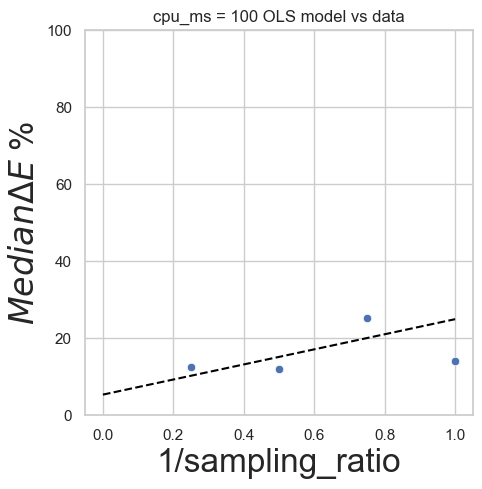

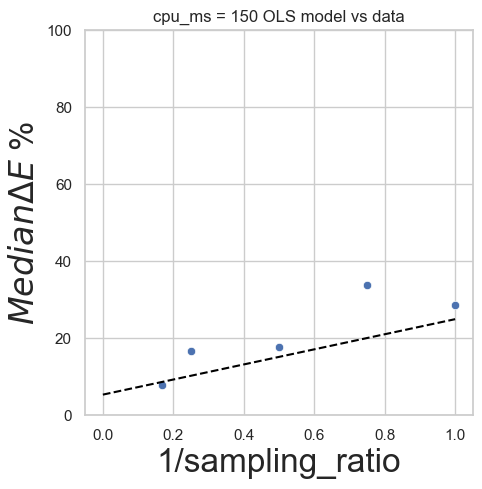

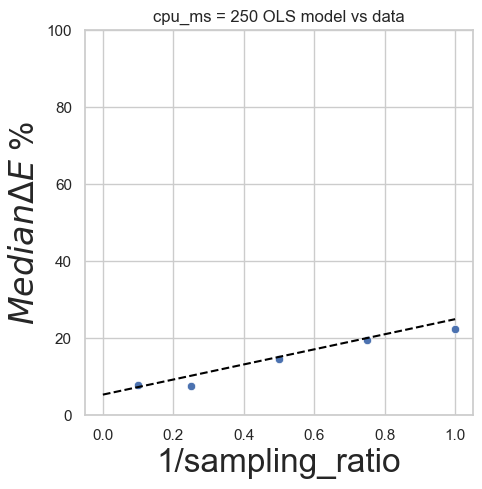

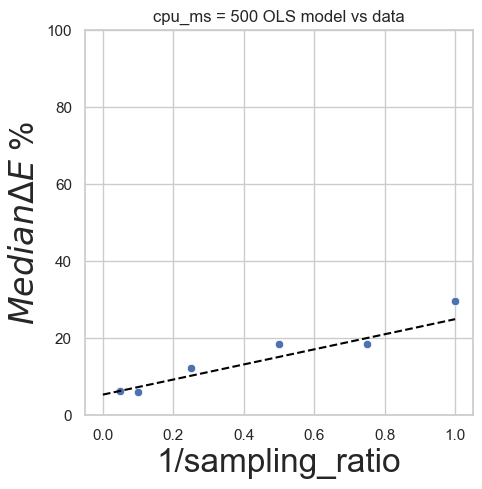

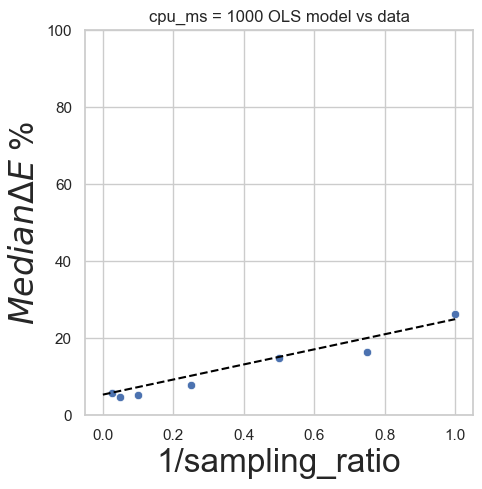

In [149]:
span_lengths = np.unique(df_median_n_100.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    tmp_df = df_median_n_100.drop(['sampling_ratio'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=tmp_df, x=tmp_df['recip_sampling_ratio'], y=tmp_df['median_energy_deviation'])
    #plt.errorbar(tmp_df['recip_sampling_ratio'], tmp_df['median_energy_deviation'], yerr=[tmp_df['delta_e_lower_ci'],tmp_df['delta_e_upper_ci'] ], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, reg_model_100(x_vals), color="black", linestyle="--")
    plt.ylim(0,100)
    plt.xlabel("1/sampling_ratio", fontsize=fs)
    plt.ylabel(r'$Median \Delta E$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" OLS model vs data")
    plt.show()

### OLS model: $ Median Accuracy (\\\%) = 19.6*\frac{1}{sampling\\\_ratio} + 5.3$
### where $sampling\\\_ratio = \frac{span_{ms}}{measurement\\\_interval_{ms}}$

### *** have to try with actually smaller number of samples of each cpu_ms, like n=50?

## If E shifts do we get same accuracy model? we should

#### double energy per span and rebuild model
#### n=100 per span

In [284]:
df_n_100_shifted = pd.concat([df_sample_100, df_sample_150, df_sample_250, df_sample_500, df_sample_1000])
df_n_100_shifted['energy_joules_span'] = df_n_100_shifted.energy_joules_span * 2.0

### Get Median E for each cpu_ms

In [285]:
df_median_e_cpu_sample_shifted = df_n_100_shifted[['energy_joules_span','cpu_ms']].copy()
df_median_e_cpu_sample_shifted = df_median_e_cpu_sample_shifted.groupby(['cpu_ms'], as_index=False).median()
df_median_e_cpu_sample_shifted

,cpu_ms,energy_joules_span
0,100,0.556747
1,150,0.947805
2,250,1.721369
3,500,3.661011
4,1000,7.576992


### add column with median energy for that cpu_ms to each trace_id

In [286]:
cpu_ms_vals = np.unique(df_n_100_shifted['cpu_ms'])
for i in cpu_ms_vals:
    df_n_100_shifted.loc[df['cpu_ms'] == i, 'median_energy_cpu_ms'] = df_median_e_cpu_sample_shifted[df_median_e_cpu_sample_shifted['cpu_ms'] == i].energy_joules_span.values[0]

df_n_100_shifted.head(20)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms
18280,7c574790b36b0041518ef59a0f66df57,0.702606,100,75.0,0.556747
7894,b254232dbd4658b9e66e77fa6b4139d9,0.594976,100,100.0,0.556747
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.448090,100,50.0,0.556747
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.656696,100,100.0,0.556747
25608,92e157a233fb343f7416955f7c511137,0.585922,100,100.0,0.556747
31513,b57c891dbd5b6eeb5e2d3235a8b4a746,0.428364,100,100.0,0.556747
7402,9cc5d5dc91f491e705e07563de1da61a,0.647184,100,75.0,0.556747
29882,710c51bf52b3cbbd65f944b3244b75b0,0.500810,100,100.0,0.556747
6338,f6c432ee7d11ac90047cd85fb0e8e6e0,0.337956,100,100.0,0.556747
6306,7133397e951a8e239c0ffc6e5df4bd9c,0.519998,100,50.0,0.556747


### calculate deviation per trace E from median for that cpu_ms

In [287]:
df_n_100_shifted['energy_devation'] = (df_n_100_shifted.median_energy_cpu_ms - df_n_100_shifted.energy_joules_span) 

### and add columns for % deviation from median for that cpu_ms, sampling ratio, and accuracy
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [288]:
df_n_100_shifted['energy_deviation_pct'] = 100 * df_n_100_shifted.energy_devation / df_n_100_shifted.median_energy_cpu_ms
df_n_100_shifted['sampling_ratio'] = df_n_100_shifted.cpu_ms / df_n_100_shifted.active_interval_ms
df_n_100_shifted['energy_deviation_pct_abs'] = np.abs(df_n_100_shifted.energy_deviation_pct)
df_n_100_shifted['recip_sampling_ratio'] = 1 / df_n_100_shifted.sampling_ratio

In [207]:
df_n_100_shifted

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,recip_sampling_ratio
18280,7c574790b36b0041518ef59a0f66df57,0.702606,100,75.0,0.556747,-0.145859,-26.198435,1.333333,26.198435,0.75
7894,b254232dbd4658b9e66e77fa6b4139d9,0.594976,100,100.0,0.556747,-0.038229,-6.866494,1.000000,6.866494,1.00
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.448090,100,50.0,0.556747,0.108657,19.516405,2.000000,19.516405,0.50
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.656696,100,100.0,0.556747,-0.099949,-17.952319,1.000000,17.952319,1.00
25608,92e157a233fb343f7416955f7c511137,0.585922,100,100.0,0.556747,-0.029175,-5.240262,1.000000,5.240262,1.00
...,...,...,...,...,...,...,...,...,...,...
21695,d50b655f75f48101a446693534e087cc,8.329818,1000,50.0,7.576992,-0.752826,-9.935684,20.000000,9.935684,0.05
38747,313a66cd4fe84c7297bdfeeb00495859,7.386728,1000,50.0,7.576992,0.190264,2.511076,20.000000,2.511076,0.05
1850,feaa2f3b22d65fe1563cb822c7b40bf8,7.974970,1000,100.0,7.576992,-0.397978,-5.252454,10.000000,5.252454,0.10
1317,91b880379e797de8ec5912e7c1377fbb,7.531078,1000,500.0,7.576992,0.045914,0.605966,2.000000,0.605966,0.50


In [289]:
np.unique(df_n_100_shifted.sampling_ratio)

array([ 1.        ,  1.33333333,  2.        ,  4.        ,  4.03225806,
        4.05405405,  6.        , 10.        , 20.        , 40.        ])

In [290]:
df_n_100_shifted['sampling_ratio'] = df_n_100_shifted['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)
df_n_100_shifted['recip_sampling_ratio'] = 1 / df_n_100_shifted.sampling_ratio
np.unique(df_n_100_shifted.sampling_ratio)

array([ 1.        ,  1.33333333,  2.        ,  4.        ,  6.        ,
       10.        , 20.        , 40.        ])

#### Rebuild dataframe of median accuracy values

In [291]:
df_median_n_100_shifted = df_n_100_shifted.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
df_median_n_100_shifted = df_median_n_100_shifted.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
df_median_n_100_shifted['recip_sampling_ratio'] = 1 / df_median_n_100_shifted.sampling_ratio
df_median_n_100_shifted

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio
0,100,1.000000,13.964332,1.000000
1,100,1.333333,25.290302,0.750000
2,100,2.000000,11.872359,0.500000
3,100,4.000000,12.556332,0.250000
4,150,1.000000,28.592590,1.000000
5,150,1.333333,33.738691,0.750000
6,150,2.000000,17.631475,0.500000
7,150,4.000000,16.595819,0.250000
8,150,6.000000,7.745475,0.166667
9,250,1.000000,22.263501,1.000000


### Now add OLS model and check fits

### Model with only recip sampling ratio to avoid multicollinearity

In [292]:
df_median_n_100_shifted.columns

Index(['cpu_ms', 'sampling_ratio', 'median_energy_deviation',
       'recip_sampling_ratio'],
      dtype='object')

#### Only considering span lengths <= 1000 ms for now

In [293]:
# define x & y
df_sub1000_n_100_shifted = df_median_n_100_shifted.query("cpu_ms <= 1000.0")
X = df_sub1000_n_100_shifted.drop(['cpu_ms','sampling_ratio', 'median_energy_deviation'], axis=1)
       #'delta_e_upper_ci', 'delta_e_lower_ci'], axis=1)
y = df_sub1000_n_100_shifted['median_energy_deviation']


#### do a train/test split of 80/20 so I can determine RMSE and $R^{2}$ on out-of-sample data

In [294]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

#### build model and check coefficients

In [295]:
mlr100_shifted = LinearRegression()  
mlr100_shifted.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr100_shifted.coef_)), "\n Intercept: ", mlr100_shifted.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(19.597381451135753))] 
 Intercept:  5.321864008691341


In [296]:
# make predictions based on test data
y_pred = mlr100_shifted.predict(x_test)

In [297]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  5.818455559722808
The R^2 is:  0.5815048188319807


#### Much higher RMSE and an $R^{2} = 0.58$ is just OK

#### but a simple linear shift results in same model as it should

### what about if energy shifts by small random % from 100% to 150% for each value?

In [315]:
randoms = np.random.randint(10,15+1,500)/10.0
randoms

array([1.3, 1.1, 1.5, 1.1, 1.3, 1.5, 1.2, 1.2, 1.4, 1.2, 1.1, 1.4, 1.4,
       1.2, 1.3, 1. , 1.1, 1.1, 1.1, 1. , 1.5, 1.5, 1.3, 1.1, 1.4, 1.3,
       1.2, 1.3, 1.5, 1. , 1.1, 1.1, 1.5, 1.5, 1.3, 1. , 1. , 1.5, 1.4,
       1.3, 1.1, 1.4, 1.5, 1.1, 1.5, 1.4, 1.3, 1.5, 1.4, 1.2, 1.5, 1.4,
       1.1, 1.1, 1. , 1.5, 1.5, 1.4, 1.2, 1.4, 1.5, 1. , 1. , 1.5, 1. ,
       1.4, 1.1, 1.4, 1. , 1.1, 1.1, 1.2, 1.1, 1.4, 1.4, 1.5, 1.4, 1. ,
       1.4, 1.1, 1.4, 1.1, 1.3, 1.2, 1.5, 1.3, 1.1, 1. , 1.5, 1.1, 1.1,
       1.2, 1.1, 1. , 1.1, 1.4, 1.1, 1.1, 1. , 1. , 1. , 1. , 1.1, 1.2,
       1.5, 1.2, 1.4, 1.4, 1. , 1.1, 1.4, 1.3, 1.3, 1.5, 1.2, 1.1, 1.4,
       1. , 1. , 1.1, 1.1, 1.5, 1.5, 1. , 1.5, 1. , 1. , 1.4, 1.1, 1.1,
       1. , 1.2, 1.4, 1.1, 1.5, 1. , 1.5, 1.5, 1.1, 1.2, 1.1, 1.1, 1.2,
       1. , 1.4, 1.5, 1.2, 1. , 1.1, 1.3, 1. , 1.1, 1. , 1.1, 1.2, 1.1,
       1.1, 1. , 1.4, 1.5, 1.1, 1.3, 1.3, 1.5, 1.4, 1.3, 1. , 1. , 1.4,
       1.3, 1.3, 1. , 1.1, 1.4, 1.5, 1.3, 1.3, 1.5, 1.2, 1.2, 1.

In [316]:
df_n_100_shifted = pd.concat([df_sample_100, df_sample_150, df_sample_250, df_sample_500, df_sample_1000])
df_n_100_shifted['energy_joules_span'] = np.multiply(df_n_100_shifted.energy_joules_span, randoms)

In [317]:
df_n_100_shifted

,trace_id,energy_joules_span,cpu_ms,active_interval_ms
18280,7c574790b36b0041518ef59a0f66df57,0.456694,100,75.0
7894,b254232dbd4658b9e66e77fa6b4139d9,0.327237,100,100.0
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.336067,100,50.0
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.361183,100,100.0
25608,92e157a233fb343f7416955f7c511137,0.380849,100,100.0
...,...,...,...,...
21695,d50b655f75f48101a446693534e087cc,5.414382,1000,50.0
38747,313a66cd4fe84c7297bdfeeb00495859,3.693364,1000,50.0
1850,feaa2f3b22d65fe1563cb822c7b40bf8,5.981228,1000,100.0
1317,91b880379e797de8ec5912e7c1377fbb,5.648308,1000,500.0


### Get Median E for each cpu_ms

In [318]:
df_median_e_cpu_sample_shifted = df_n_100_shifted[['energy_joules_span','cpu_ms']].copy()
df_median_e_cpu_sample_shifted = df_median_e_cpu_sample_shifted.groupby(['cpu_ms'], as_index=False).median()
df_median_e_cpu_sample_shifted

,cpu_ms,energy_joules_span
0,100,0.340235
1,150,0.567423
2,250,1.088986
3,500,2.308570
4,1000,4.594686


### add column with median energy for that cpu_ms to each trace_id

In [319]:
cpu_ms_vals = np.unique(df_n_100_shifted['cpu_ms'])
for i in cpu_ms_vals:
    df_n_100_shifted.loc[df['cpu_ms'] == i, 'median_energy_cpu_ms'] = df_median_e_cpu_sample_shifted[df_median_e_cpu_sample_shifted['cpu_ms'] == i].energy_joules_span.values[0]

df_n_100_shifted.head(20)

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms
18280,7c574790b36b0041518ef59a0f66df57,0.456694,100,75.0,0.340235
7894,b254232dbd4658b9e66e77fa6b4139d9,0.327237,100,100.0,0.340235
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.336067,100,50.0,0.340235
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.361183,100,100.0,0.340235
25608,92e157a233fb343f7416955f7c511137,0.380849,100,100.0,0.340235
31513,b57c891dbd5b6eeb5e2d3235a8b4a746,0.321273,100,100.0,0.340235
7402,9cc5d5dc91f491e705e07563de1da61a,0.388310,100,75.0,0.340235
29882,710c51bf52b3cbbd65f944b3244b75b0,0.300486,100,100.0,0.340235
6338,f6c432ee7d11ac90047cd85fb0e8e6e0,0.236569,100,100.0,0.340235
6306,7133397e951a8e239c0ffc6e5df4bd9c,0.311999,100,50.0,0.340235


### calculate deviation per trace E from median for that cpu_ms

In [320]:
df_n_100_shifted['energy_devation'] = (df_n_100_shifted.median_energy_cpu_ms - df_n_100_shifted.energy_joules_span) 

### and add columns for % deviation from median for that cpu_ms, sampling ratio, and accuracy
#### an accuracy of 1.0 would mean it got the span mean energy value exactly for that trace

In [321]:
df_n_100_shifted['energy_deviation_pct'] = 100 * df_n_100_shifted.energy_devation / df_n_100_shifted.median_energy_cpu_ms
df_n_100_shifted['sampling_ratio'] = df_n_100_shifted.cpu_ms / df_n_100_shifted.active_interval_ms
df_n_100_shifted['energy_deviation_pct_abs'] = np.abs(df_n_100_shifted.energy_deviation_pct)
df_n_100_shifted['recip_sampling_ratio'] = 1 / df_n_100_shifted.sampling_ratio

In [322]:
df_n_100_shifted

,trace_id,energy_joules_span,cpu_ms,active_interval_ms,median_energy_cpu_ms,energy_devation,energy_deviation_pct,sampling_ratio,energy_deviation_pct_abs,recip_sampling_ratio
18280,7c574790b36b0041518ef59a0f66df57,0.456694,100,75.0,0.340235,-0.116459,-34.229137,1.333333,34.229137,0.75
7894,b254232dbd4658b9e66e77fa6b4139d9,0.327237,100,100.0,0.340235,0.012998,3.820232,1.000000,3.820232,1.00
40910,ba7eefa79200f7fad6f40edf43e3b2a1,0.336067,100,50.0,0.340235,0.004167,1.224758,2.000000,1.224758,0.50
41829,93f3c97a16bfcdfd8fa9cad8007ab412,0.361183,100,100.0,0.340235,-0.020948,-6.157003,1.000000,6.157003,1.00
25608,92e157a233fb343f7416955f7c511137,0.380849,100,100.0,0.340235,-0.040615,-11.937280,1.000000,11.937280,1.00
...,...,...,...,...,...,...,...,...,...,...
21695,d50b655f75f48101a446693534e087cc,5.414382,1000,50.0,4.594686,-0.819696,-17.840090,20.000000,17.840090,0.05
38747,313a66cd4fe84c7297bdfeeb00495859,3.693364,1000,50.0,4.594686,0.901322,19.616612,20.000000,19.616612,0.05
1850,feaa2f3b22d65fe1563cb822c7b40bf8,5.981228,1000,100.0,4.594686,-1.386542,-30.177078,10.000000,30.177078,0.10
1317,91b880379e797de8ec5912e7c1377fbb,5.648308,1000,500.0,4.594686,-1.053623,-22.931337,2.000000,22.931337,0.50


In [323]:
np.unique(df_n_100_shifted.sampling_ratio)

array([ 1.        ,  1.33333333,  2.        ,  4.        ,  4.03225806,
        4.05405405,  6.        , 10.        , 20.        , 40.        ])

In [324]:
df_n_100_shifted['sampling_ratio'] = df_n_100_shifted['sampling_ratio'].apply(lambda x: 4.000000 if ((x > 4) & (x < 5)) else x)
df_n_100_shifted['recip_sampling_ratio'] = 1 / df_n_100_shifted.sampling_ratio
np.unique(df_n_100_shifted.sampling_ratio)

array([ 1.        ,  1.33333333,  2.        ,  4.        ,  6.        ,
       10.        , 20.        , 40.        ])

#### Rebuild dataframe of median accuracy values

In [325]:
df_median_n_100_shifted = df_n_100_shifted.loc[:, ['cpu_ms','sampling_ratio','energy_deviation_pct_abs']].groupby(['cpu_ms','sampling_ratio'], as_index=False).median()
df_median_n_100_shifted = df_median_n_100_shifted.rename(columns={'cpu_ms':'cpu_ms','sampling_ratio':'sampling_ratio','energy_deviation_pct_abs':'median_energy_deviation'})
df_median_n_100_shifted['recip_sampling_ratio'] = 1 / df_median_n_100_shifted.sampling_ratio
df_median_n_100_shifted

,cpu_ms,sampling_ratio,median_energy_deviation,recip_sampling_ratio
0,100,1.000000,14.526361,1.000000
1,100,1.333333,17.708828,0.750000
2,100,2.000000,14.077656,0.500000
3,100,4.000000,15.144817,0.250000
4,150,1.000000,23.816134,1.000000
5,150,1.333333,31.092630,0.750000
6,150,2.000000,18.882213,0.500000
7,150,4.000000,20.121765,0.250000
8,150,6.000000,19.243020,0.166667
9,250,1.000000,22.738538,1.000000


### Now add OLS model and check fits

### Model with only recip sampling ratio to avoid multicollinearity

In [326]:
df_median_n_100_shifted.columns

Index(['cpu_ms', 'sampling_ratio', 'median_energy_deviation',
       'recip_sampling_ratio'],
      dtype='object')

#### Only considering span lengths <= 1000 ms for now

In [327]:
# define x & y
df_sub1000_n_100_shifted = df_median_n_100_shifted.query("cpu_ms <= 1000.0")
X = df_sub1000_n_100_shifted.drop(['cpu_ms','sampling_ratio', 'median_energy_deviation'], axis=1)
       #'delta_e_upper_ci', 'delta_e_lower_ci'], axis=1)
y = df_sub1000_n_100_shifted['median_energy_deviation']


#### do a train/test split of 80/20 so I can determine RMSE and $R^{2}$ on out-of-sample data

In [328]:
# create train/test split of data, 80/20 split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 47)

#### build model and check coefficients

In [329]:
mlr100_shifted = LinearRegression()  
mlr100_shifted.fit(x_train, y_train)
# output model coefficients
print("Coefficients: ", list(zip(X, mlr100_shifted.coef_)), "\n Intercept: ", mlr100_shifted.intercept_)

Coefficients:  [('recip_sampling_ratio', np.float64(8.42037660999954))] 
 Intercept:  14.45723467021322


In [330]:
# make predictions based on test data
y_pred = mlr100_shifted.predict(x_test)

In [331]:
# calculate rmse
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("The RMSE is: ", rmse)
print("The R^2 is: ", r2)

The RMSE is:  4.761433409227255
The R^2 is:  0.3560911383652735


#### make function for using regression model in plot

In [341]:
# make function for using regression model
def reg_model_100_shifted(recip_sampling_ratio):
    return (mlr100_shifted.intercept_ + mlr100_shifted.coef_[0]*recip_sampling_ratio)

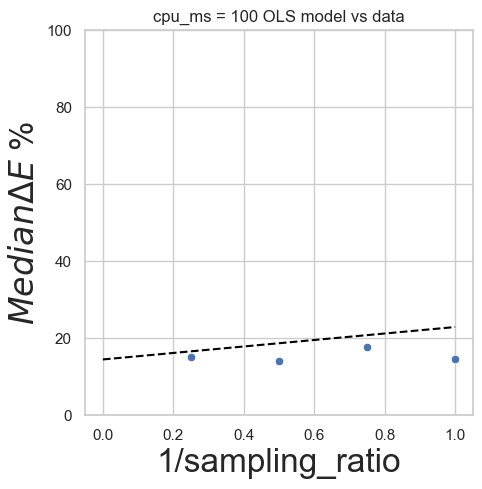

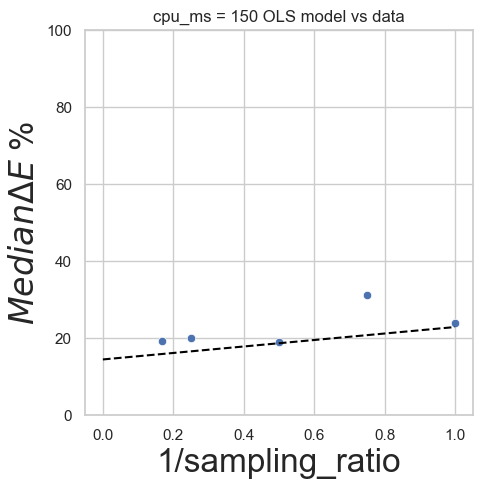

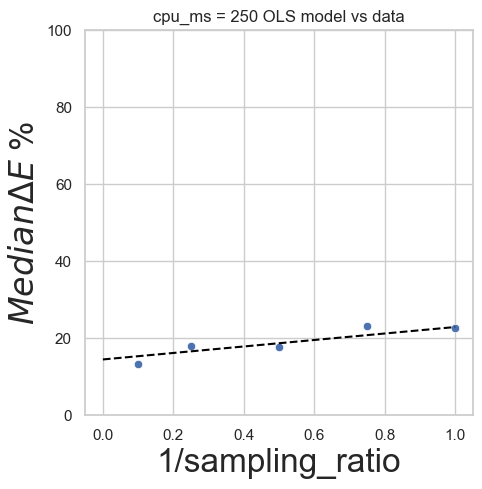

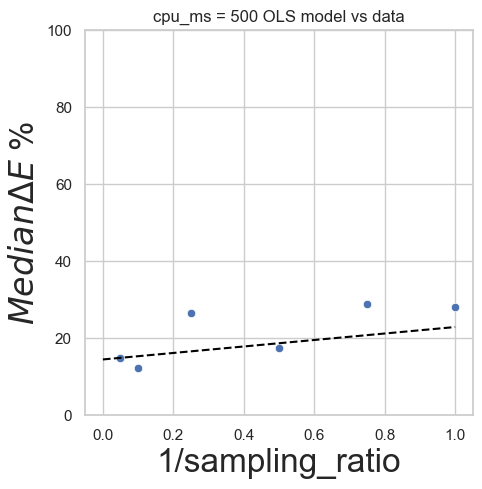

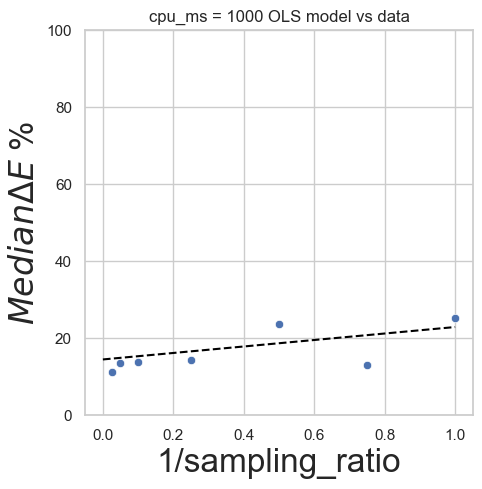

In [333]:
span_lengths = np.unique(df_median_n_100.query("cpu_ms <= 1000.0").cpu_ms)

# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

# only up to 1000 ms spans
for i in span_lengths:
    tmp_df = df_median_n_100_shifted.drop(['sampling_ratio'], axis=1).query("cpu_ms == "+str(i))
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=tmp_df, x=tmp_df['recip_sampling_ratio'], y=tmp_df['median_energy_deviation'])
    #plt.errorbar(tmp_df['recip_sampling_ratio'], tmp_df['median_energy_deviation'], yerr=[tmp_df['delta_e_lower_ci'],tmp_df['delta_e_upper_ci'] ], fmt='none', capsize=2,color='black')
    plt.plot(x_vals, reg_model_100(x_vals), color="black", linestyle="--")
    plt.ylim(0,100)
    plt.xlabel("1/sampling_ratio", fontsize=fs)
    plt.ylabel(r'$Median \Delta E$ %', fontsize=fs)
    plt.title("cpu_ms = "+str(i)+" OLS model vs data")
    plt.show()

### OLS model: $ Median Accuracy (\\\%) = 8.4*\frac{1}{sampling\\\_ratio} + 14.5$
### where $sampling\\\_ratio = \frac{span_{ms}}{measurement\\\_interval_{ms}}$

#### Hypothesis test - are those accuracy models different?

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.176e+31
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          7.76e-137
Time:                        11:20:17   Log-Likelihood:                 351.90
No. Observations:                  11   AIC:                            -699.8
Df Residuals:                       9   BIC:                            -699.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.1354   1.93e-15  -4.74e+15      0.0

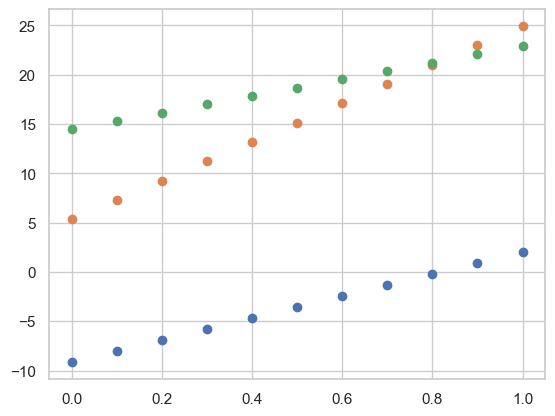

In [354]:
# range of recip_ratio values for plots
x_vals = np.arange(0,1.1,0.1)

X = x_vals
y1 = reg_model_100(x_vals)
y2 = reg_model_100_shifted(x_vals)
y = y1 - y2

X = sm.add_constant(X)
model = sm.OLS(y, X).fit() # Fit the OLS regression model
print(model.summary())


plt.scatter(x_vals,y)
plt.scatter(x_vals,y1,label='unshifted')
plt.scatter(x_vals,y2,label='shifted')
# mlr = LinearRegression()  
# mlr.fit(x_vals.reshape(-1, 1), y)
# # output model coefficients
# print("Coefficients: ", list(zip(X, mlr.coef_)), "\n Intercept: ", mlr.intercept_)

#### 95% conf range on slope does not contain zero so they are not significantly different